## Workbook containing the proposed figures for chapter 1 

Table reporting of streamflow performance (NSE and KGE quartiles broken down by glaciation)

In [1]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, TEST_START_YEAR, TEST_END_YEAR

ENSEMBLE_MEMBERS = 10
model_list = ['area', 'baseline', 'topographic', 'phase-split']

# define the evaluation metrics (NSE, KGE, and PBIAS), robust to missing values (NaNs)
def nse(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    sim_masked = sim[mask]
    denom = np.sum((obs_masked - np.mean(obs_masked)) ** 2)
    if denom == 0: return np.nan
    return 1 - np.sum((obs_masked - sim_masked) ** 2) / denom

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def pbias(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    denom = np.sum(obs_masked)
    if denom == 0: return np.nan
    return 100 * np.sum(sim[mask] - obs_masked) / denom

# load the ground truth data
static_atts = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
streamflow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0)

# Convert the ground truth streamflow data to units of mm/day
streamflow.index = pd.to_datetime(streamflow.index)
test_years_mask = (streamflow.index.year >= TEST_START_YEAR) & (streamflow.index.year <= TEST_END_YEAR)
streamflow_test = streamflow.loc[test_years_mask]

# Align the static attributes order exactly with the streamflow columns
common_columns = streamflow_test.columns.intersection(static_atts.index)
streamflow_test = streamflow_test[common_columns]
areas = static_atts.loc[common_columns, 'basin_area_km2']

# Vectorized operation across all 290 columns at once
# (m3/s) / (km2 * 1e6) * 86400 s/day * 1000 mm/m -> mm/day
conversion_factor = 86400 * 1e3 / (areas * 1e6)
streamflow_mm = streamflow_test.multiply(conversion_factor, axis=1)

# Identify glaciated stations
glacier_col = [c for c in static_atts.columns if 'glacier_pct' in c.lower()][0]
glaciated_stations = static_atts[static_atts[glacier_col] > 0].index.intersection(streamflow_mm.columns)
all_stations = streamflow_mm.columns

# Container for final report records
summary_records = []

for model in model_list:
    # Storage arrays for metrics per member per station
    # Shape: (Ensemble_Members, Stations)
    member_kge_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_nse_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_pbias_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    
    # Track ensemble mean time-series prediction per station
    ens_mean_preds = pd.DataFrame(0.0, index=streamflow_mm.index, columns=all_stations)
    
    # 1. First Pass: Load all member predictions, calculate individual metrics, and build ensemble mean
    for i in range(ENSEMBLE_MEMBERS):
        file_fact = OUTPUT_DATA_DIR / model / f"{model}_preds_member_{i}.csv"
        # Assuming predictions columns match station IDs and rows match the date index
        preds = pd.read_csv(file_fact, index_col=0)
        preds.index = pd.to_datetime(preds.index)
        preds = preds.loc[streamflow_mm.index, all_stations] # Align perfectly
        
        ens_mean_preds += preds / ENSEMBLE_MEMBERS
        
        for s_idx, station in enumerate(all_stations):
            obs_series = streamflow_mm[station].values
            sim_series = preds[station].values
            member_kge_all[i, s_idx] = kge(obs_series, sim_series)
            member_nse_all[i, s_idx] = nse(obs_series, sim_series)
            member_pbias_all[i, s_idx] = pbias(obs_series, sim_series)

    # 2. Compute metrics for the actual Ensemble Mean time series
    ens_mean_kge_all = np.array([kge(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_nse_all = np.array([nse(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_pbias_all = np.array([pbias(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])

    # 3. Aggregate metrics over spatial subsets (All vs. Glaciated)
    for subset_name, subset_stations in [("All Basins", all_stations), ("Glaciated Basins", glaciated_stations)]:
        # Get positional indices of subset stations relative to the 'all_stations' list
        sub_indices = [all_stations.get_loc(st) for st in subset_stations]
        
        # Individual member spatial aggregations
        sub_member_kge = np.nanmedian(member_kge_all[:, sub_indices], axis=1)
        sub_member_nse = np.nanmedian(member_nse_all[:, sub_indices], axis=1)
        sub_member_pbias = np.nanmedian(member_pbias_all[:, sub_indices], axis=1)
        
        sub_member_kge_gt07 = np.sum(member_kge_all[:, sub_indices] > 0.7, axis=1)
        sub_member_kge_lt0 = np.sum(member_kge_all[:, sub_indices] < 0.0, axis=1)
        
        # Ensemble mean spatial aggregations
        ens_mean_kge_med = np.nanmedian(ens_mean_kge_all[sub_indices])
        ens_mean_nse_med = np.nanmedian(ens_mean_nse_all[sub_indices])
        ens_mean_pbias_med = np.nanmedian(ens_mean_pbias_all[sub_indices])
        ens_mean_kge_gt07 = np.sum(ens_mean_kge_all[sub_indices] > 0.7)
        ens_mean_kge_lt0 = np.sum(ens_mean_kge_all[sub_indices] < 0.0)
        
        # Format strings as: Single Member Mean ± Std [Ensemble Mean Prediction value]
        def format_stat(member_arr, mean_val, is_int=False):
            fmt = "{:.0f}" if is_int else "{:.3f}"
            return f"{fmt.format(np.mean(member_arr))} ± {fmt.format(np.std(member_arr))} [{fmt.format(mean_val)}]"

        summary_records.append({
            "Model": model,
            "Subset": subset_name,
            "Median KGE": format_stat(sub_member_kge, ens_mean_kge_med),
            "Median NSE": format_stat(sub_member_nse, ens_mean_nse_med),
            "Median PBIAS (%)": format_stat(sub_member_pbias, ens_mean_pbias_med, is_int=False),
            "Stations KGE > 0.7": format_stat(sub_member_kge_gt07, ens_mean_kge_gt07, is_int=True),
            "Stations KGE < 0.0": format_stat(sub_member_kge_lt0, ens_mean_kge_lt0, is_int=True)
        })

# 4. Generate beautiful multi-index layout for clean terminal printing
df_res = pd.DataFrame(summary_records).set_index(["Subset", "Model"])

print("\n" + "="*95)
print("   STREAMFLOW MODEL BENCHMARK TEST SUMMARY")
print("   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]")
print("="*95)
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.colheader_justify', 'center'):
    print(df_res)
print("="*95 + "\n")


   STREAMFLOW MODEL BENCHMARK TEST SUMMARY
   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]
                                   Median KGE             Median NSE             Median PBIAS (%)      Stations KGE > 0.7 Stations KGE < 0.0
Subset           Model                                                                                                                      
All Basins       area         0.491 ± 0.098 [0.526]  0.509 ± 0.075 [0.567]  -14.478 ± 10.332 [-12.535]     76 ± 16 [85]      30 ± 24 [17]   
Glaciated Basins area         0.767 ± 0.064 [0.794]  0.769 ± 0.064 [0.820]     -1.964 ± 5.470 [-1.232]     60 ± 11 [69]         0 ± 0 [0]   
All Basins       baseline     0.275 ± 0.302 [0.352]  0.349 ± 0.239 [0.453]  -31.906 ± 26.380 [-29.884]     49 ± 28 [44]      70 ± 64 [38]   
Glaciated Basins baseline     0.560 ± 0.290 [0.645]  0.570 ± 0.335 [0.735]  -18.232 ± 22.726 [-16.576]     40 ± 22 [37]        7 ± 16 [0]   
All Basins       topographic  0.688 ± 0.0

In [2]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, TEST_START_YEAR, TEST_END_YEAR

ENSEMBLE_MEMBERS = 10
model_list = ['topographic_lstm']

# define the evaluation metrics (NSE, KGE, and PBIAS), robust to missing values (NaNs)
def nse(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    sim_masked = sim[mask]
    denom = np.sum((obs_masked - np.mean(obs_masked)) ** 2)
    if denom == 0: return np.nan
    return 1 - np.sum((obs_masked - sim_masked) ** 2) / denom

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def pbias(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    denom = np.sum(obs_masked)
    if denom == 0: return np.nan
    return 100 * np.sum(sim[mask] - obs_masked) / denom

# load the ground truth data
static_atts = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
streamflow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0)

# Convert the ground truth streamflow data to units of mm/day
streamflow.index = pd.to_datetime(streamflow.index)
test_years_mask = (streamflow.index.year >= TEST_START_YEAR) & (streamflow.index.year <= TEST_END_YEAR)
streamflow_test = streamflow.loc[test_years_mask]

# Align the static attributes order exactly with the streamflow columns
common_columns = streamflow_test.columns.intersection(static_atts.index)
streamflow_test = streamflow_test[common_columns]
areas = static_atts.loc[common_columns, 'basin_area_km2']

# Vectorized operation across all 290 columns at once
# (m3/s) / (km2 * 1e6) * 86400 s/day * 1000 mm/m -> mm/day
conversion_factor = 86400 * 1e3 / (areas * 1e6)
streamflow_mm = streamflow_test.multiply(conversion_factor, axis=1)

# Identify glaciated stations
glacier_col = [c for c in static_atts.columns if 'glacier_pct' in c.lower()][0]
glaciated_stations = static_atts[static_atts[glacier_col] > 0].index.intersection(streamflow_mm.columns)
all_stations = streamflow_mm.columns

# Container for final report records
summary_records = []

for model in model_list:
    # Storage arrays for metrics per member per station
    # Shape: (Ensemble_Members, Stations)
    member_kge_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_nse_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_pbias_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    
    # Track ensemble mean time-series prediction per station
    ens_mean_preds = pd.DataFrame(0.0, index=streamflow_mm.index, columns=all_stations)
    
    # 1. First Pass: Load all member predictions, calculate individual metrics, and build ensemble mean
    for i in range(ENSEMBLE_MEMBERS):
        file_fact = OUTPUT_DATA_DIR / model / f"{model}_preds_member_{i}.csv"
        # Assuming predictions columns match station IDs and rows match the date index
        preds = pd.read_csv(file_fact, index_col=0)
        preds.index = pd.to_datetime(preds.index)
        preds = preds.loc[streamflow_mm.index, all_stations] # Align perfectly
        
        ens_mean_preds += preds / ENSEMBLE_MEMBERS
        
        for s_idx, station in enumerate(all_stations):
            obs_series = streamflow_mm[station].values
            sim_series = preds[station].values
            member_kge_all[i, s_idx] = kge(obs_series, sim_series)
            member_nse_all[i, s_idx] = nse(obs_series, sim_series)
            member_pbias_all[i, s_idx] = pbias(obs_series, sim_series)

    # 2. Compute metrics for the actual Ensemble Mean time series
    ens_mean_kge_all = np.array([kge(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_nse_all = np.array([nse(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_pbias_all = np.array([pbias(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])

    # 3. Aggregate metrics over spatial subsets (All vs. Glaciated)
    for subset_name, subset_stations in [("All Basins", all_stations), ("Glaciated Basins", glaciated_stations)]:
        # Get positional indices of subset stations relative to the 'all_stations' list
        sub_indices = [all_stations.get_loc(st) for st in subset_stations]
        
        # Individual member spatial aggregations
        sub_member_kge = np.nanmedian(member_kge_all[:, sub_indices], axis=1)
        sub_member_nse = np.nanmedian(member_nse_all[:, sub_indices], axis=1)
        sub_member_pbias = np.nanmedian(member_pbias_all[:, sub_indices], axis=1)
        
        sub_member_kge_gt07 = np.sum(member_kge_all[:, sub_indices] > 0.7, axis=1)
        sub_member_kge_lt0 = np.sum(member_kge_all[:, sub_indices] < 0.0, axis=1)

        sub_member_nse_lt0 = np.sum(member_nse_all[:, sub_indices] < 0.0, axis=1)
        
        # Ensemble mean spatial aggregations
        ens_mean_kge_med = np.nanmedian(ens_mean_kge_all[sub_indices])
        ens_mean_nse_med = np.nanmedian(ens_mean_nse_all[sub_indices])
        ens_mean_pbias_med = np.nanmedian(ens_mean_pbias_all[sub_indices])
        ens_mean_kge_gt07 = np.sum(ens_mean_kge_all[sub_indices] > 0.7)
        ens_mean_kge_lt0 = np.sum(ens_mean_kge_all[sub_indices] < 0.0)
        ens_mean_nse_lt0 = np.sum(ens_mean_nse_all[sub_indices] < 0.0)
        # Format strings as: Single Member Mean ± Std [Ensemble Mean Prediction value]
        def format_stat(member_arr, mean_val, is_int=False):
            fmt = "{:.0f}" if is_int else "{:.2f}"
            return f"{fmt.format(np.mean(member_arr))} ± {fmt.format(np.std(member_arr))} [{fmt.format(mean_val)}]"

        summary_records.append({
            "Model": model,
            "Subset": subset_name,
            "Median KGE": format_stat(sub_member_kge, ens_mean_kge_med),
            "Median NSE": format_stat(sub_member_nse, ens_mean_nse_med),
            "Median PBIAS (%)": format_stat(sub_member_pbias, ens_mean_pbias_med, is_int=False),
            "Stations KGE > 0.7": format_stat(sub_member_kge_gt07, ens_mean_kge_gt07, is_int=True),
            "Stations KGE < 0.0": format_stat(sub_member_kge_lt0, ens_mean_kge_lt0, is_int=True),
            "Stations NSE < 0.0": format_stat(sub_member_nse_lt0, ens_mean_nse_lt0, is_int=True)
        })

# 4. Generate beautiful multi-index layout for clean terminal printing
df_res = pd.DataFrame(summary_records).set_index(["Subset", "Model"])

print("\n" + "="*95)
print("   STREAMFLOW MODEL BENCHMARK TEST SUMMARY")
print("   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]")
print("="*95)
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.colheader_justify', 'center'):
    print(df_res)
print("="*95 + "\n")


   STREAMFLOW MODEL BENCHMARK TEST SUMMARY
   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]
                                       Median KGE          Median NSE        Median PBIAS (%)   Stations KGE > 0.7 Stations KGE < 0.0 Stations NSE < 0.0
Subset           Model                                                                                                                                  
All Basins       topographic_lstm  0.70 ± 0.02 [0.71]  0.72 ± 0.01 [0.75]  -4.65 ± 1.86 [-4.98]    134 ± 7 [135]       10 ± 1 [9]          7 ± 2 [6]    
Glaciated Basins topographic_lstm  0.89 ± 0.02 [0.91]  0.90 ± 0.00 [0.91]   -0.21 ± 1.57 [0.20]      83 ± 2 [83]        0 ± 0 [0]          0 ± 0 [0]    



Define standard inputs

In [8]:
# general variables and imports
import pandas as pd
import numpy as np
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, OUTPUT_GLACIER_VOL_FILES

ENSEMBLE_MEMBERS = 10

# load observed streaflow and static attributes
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# load best model predictions and compute ensemble mean
best_model = 'topographic_lstm'
# best_model = 'phase-split'
df_preds = []
df_cf_preds = []
for i in range(ENSEMBLE_MEMBERS):
    file_fact = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_member_{i}.csv"
    file_cf = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_noglacier_member_{i}.csv"
    df_pred = pd.read_csv(file_fact, index_col=0)
    df_cf_pred = pd.read_csv(file_cf, index_col=0)
    df_pred.index = pd.to_datetime(df_pred.index)
    df_cf_pred.index = pd.to_datetime(df_cf_pred.index)
    df_preds.append(df_pred)
    df_cf_preds.append(df_cf_pred)
df_pred = pd.concat(df_preds).groupby(level=0).mean()
df_cf_pred = pd.concat(df_cf_preds).groupby(level=0).mean()

# load the mass balance modeled meltwater contribution for each station
df_mbs = []
for i in range(len(OUTPUT_GLACIER_VOL_FILES)):
    df_mbs.append(pd.read_csv(OUTPUT_GLACIER_VOL_FILES[i], index_col=0, parse_dates=True))
df_mb = pd.concat(df_mbs).groupby(level=0).mean()
df_mb_range = pd.concat(df_mbs).groupby(level=0).agg(['min', 'max'])

# create a list of stations that are glaciated and have valid predictions
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index.intersection(df_mb.columns)
print(f"Total stations with predictions: {len(df_pred.columns)}")
print(f"Glaciated stations with predictions: {len(glaciated_stations)}")

# define delta-Q and mass balance predictions for glaciated stations
dq_pred = df_pred[glaciated_stations] - df_cf_pred[glaciated_stations]  # Predicted glacier contribution (mm/day)
mb_pred = df_mb[glaciated_stations]  # Modeled glacier contribution (mm/day)
mb_pred_range = df_mb_range[glaciated_stations]  # Range of modeled glacier contribution (MCM)

# generate ensemble range of dq
dq_preds = []
for i in range(ENSEMBLE_MEMBERS):
    dq_preds.append(df_preds[i][glaciated_stations] - df_cf_preds[i][glaciated_stations])
dq_pred_range = pd.concat(dq_preds).groupby(level=0).agg(['min', 'max'])

# convert to units of MCM
dq_pred_mcm = dq_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3
mb_pred_mcm = mb_pred.multiply(df_attr.loc[glaciated_stations, 'basin_area_km2'], axis=1) / 1e3

# convert to units of mm over glacier area
dq_pred_mm_glacier = dq_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)
mb_pred_mm_glacier = mb_pred.divide((df_attr.loc[glaciated_stations, 'glacier_pct'] / 100), axis=1)

# perform imputation on the ground truth streamflow data
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())
q_obs_filtered = df_obs_imputed[glaciated_stations]

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

Total stations with predictions: 269
Glaciated stations with predictions: 87


Sketch of counterfactual hypothesis

Solved Glacial Peak Amplitude: 1.023


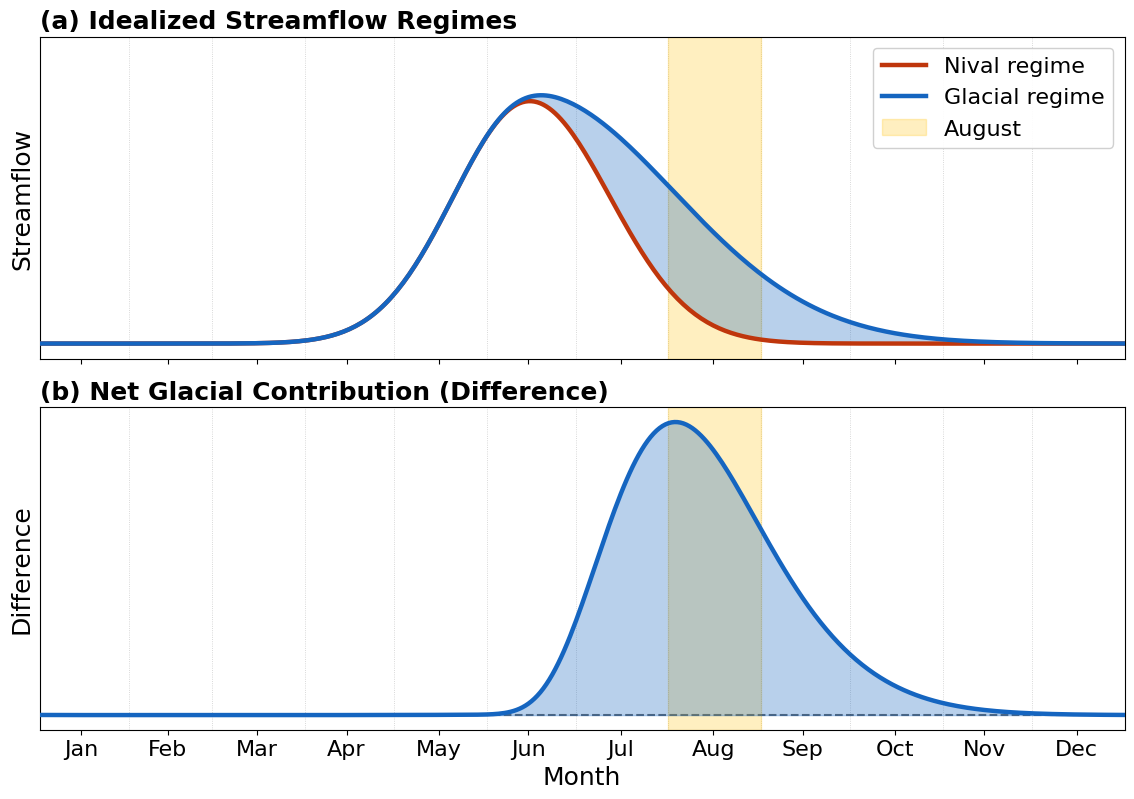


Physics simulation basis:
• T: sinusoidal seasonal forcing (−8→+18 °C)
• Precip: stochastic daily, autumn-enhanced
• Snow/rain split: linear T-threshold (0–2 °C)
• Snowpack: mass-balance + degree-day melt
  (DDF_snow = 4.0 mm °C⁻¹ day⁻¹)
• Glacier ice: DDF_ice = 8.5 mm °C⁻¹ day⁻¹
  (bare ice exposed after firn exhausted)
• ET: T-dependent, suppressed at high elevation
• Groundwater: linear reservoir → baseflow
• Curves: 10-year simulation, multi-year avg



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

days = 365
doy  = np.arange(1, 366, dtype=float)

# ── 1. Temperature (shared) ───────────────────────────────────────────────────
T = -8 + 13 * np.sin(np.pi * (doy - 15) / 180)   
T = gaussian_filter1d(np.tile(T,3), sigma=12)[days:2*days]

# ── 2. Precipitation (mm/day) ─────────────────────────────────────────────────
rng = np.random.default_rng(99)
P = 2.8 + 0.5*np.sin(2*np.pi*(doy-280)/365)
P += 0.3 * rng.standard_normal(days)
P = gaussian_filter1d(np.clip(np.tile(P,3), 0.3, 7), sigma=12)[days:2*days]

# ── 3. Rain/snow fraction ─────────────────────────────────────────────────────
def RF(T, Tlo=0, Thi=2):
    return np.clip((T-Tlo)/(Thi-Tlo), 0, 1)

rain_frac = RF(T)
Psnow = (1-rain_frac)*P
Prain = rain_frac*P

# ── 4. Degree-day factors ─────────────────────────────────────────────────────
DDF_snow = 4.0   
DDF_ice  = 8.5   
Tpos = np.where(T>0, T, 0.0)

# ─────────────────────────────────────────────────────────────────────────────
#  NIVAL: snowpack-only basin
# ─────────────────────────────────────────────────────────────────────────────
def simulate(nyears=10, with_glacier=False, Toffset=0.0):
    Tloc = T - Toffset
    Tpos_l = np.where(Tloc > 0, Tloc, 0.0)
    rf_l   = RF(Tloc)
    Ps_l   = (1-rf_l)*P
    Pr_l   = rf_l*P

    DDF_s  = DDF_snow
    DDF_ic = DDF_ice
    k_gw   = 0.016 if not with_glacier else 0.012
    et_fac = 0.55  if not with_glacier else 0.35

    all_Q = []
    SWE = 300.0
    GW  = 20.0
    SWE_glac = 800.0   

    for yr in range(nyears):
        if with_glacier:
            SWE_glac = 800.0   
        Q_yr = np.zeros(days)

        for i in range(days):
            SWE += Ps_l[i]
            m_snow = min(DDF_s * Tpos_l[i], SWE)
            SWE = max(SWE - m_snow, 0)

            ice_melt = 0.0
            if with_glacier:
                SWE_glac += Ps_l[i] * 0.5   
                m_gsnow = min(DDF_s * Tpos_l[i], SWE_glac)
                SWE_glac = max(SWE_glac - m_gsnow, 0)
                if SWE_glac <= 5.0 and Tpos_l[i] > 0:
                    ice_melt = DDF_ic * Tpos_l[i]
            else:
                m_gsnow = 0.0

            avail = Pr_l[i] + m_snow + m_gsnow + ice_melt
            et = 0.0 if Tloc[i] < 3 else min(et_fac * Tpos_l[i]**0.8, avail*0.5)
            avail = max(avail - et, 0)

            GW  += avail * 0.28
            bf   = k_gw * GW
            GW   = max(GW - bf, 0)
            Q_yr[i] = avail * 0.72 + bf

        all_Q.append(Q_yr)

    return np.mean(all_Q[4:], axis=0)

Qn_raw = simulate(nyears=10, with_glacier=False, Toffset=0.0)
Qg_raw = simulate(nyears=10, with_glacier=True,  Toffset=1.0)

# ── 5. Smooth (idealized average) ─────────────────────────────────────────────
def smooth(Q, sig=20):
    Q3 = np.tile(Q,3)
    return gaussian_filter1d(Q3, sigma=sig)[days:2*days]

Qn_s = smooth(Qn_raw, sig=18)
Qg_s = smooth(Qg_raw, sig=18)

# ── 6. Build final curves by DESIGN ──────────────────────────────────────────
peak_day = 165          
rise_days = 60          
fall_nival  = 65        # INCREASED from 45 to extend the nival tail
fall_glacial = 120      

def asymm_gaussian(doy, peak, rise_sigma, fall_sigma):
    d = doy - peak
    sigma = np.where(d < 0, rise_sigma, fall_sigma)
    return np.exp(-0.5 * (d/sigma)**2)

nival_freshet   = asymm_gaussian(doy, peak_day, rise_days/2.5, fall_nival/2.5)
glacial_freshet = asymm_gaussian(doy, peak_day, rise_days/2.5, fall_glacial/2.5)

base  = 0.06
amp_n = 0.94    
amp_g = 0.94    

Qn_ideal = base + amp_n * nival_freshet
Qg_ideal = base + amp_g * glacial_freshet

Qn_ideal = smooth(Qn_ideal, sig=8)
Qg_ideal = smooth(Qg_ideal, sig=8)

def rescale(Q, base_val=base, peak_val=1.0):
    mn, mx = Q.min(), Q.max()
    return base_val + (peak_val - base_val) * (Q - mn)/(mx - mn)

Qn_f = rescale(Qn_ideal, peak_val=1.0)

# ── SOLVER ──
optimal_peak = 1.0
Qg_f = rescale(Qg_ideal, peak_val=optimal_peak)

while np.min(Qg_f - Qn_f) < -0.0001:
    optimal_peak += 0.001
    Qg_f = rescale(Qg_ideal, peak_val=optimal_peak)

print(f"Solved Glacial Peak Amplitude: {optimal_peak:.3f}")

# ── 7. Verification / Month Data ──────────────────────────────────────────────
months   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_starts = [0,31,59,90,120,151,181,212,243,273,304,334]
m_ends   = [30,58,89,119,150,180,211,242,272,303,333,364]

def mmean(Q,m): return Q[m_starts[m]:m_ends[m]+1].mean()

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'hspace': 0.15})

c_niv = '#BF360C'   
c_gla = '#1565C0'   
c_aug = '#FFC107'   # Highlight color for August

# --- PANEL (a): The Idealized Regimes ---
ax1.set_title('(a) Idealized Streamflow Regimes', loc='left', fontsize=18, fontweight='bold')

ax1.fill_between(doy, Qn_f, Qg_f, interpolate=True, color=c_gla, alpha=0.3, zorder=2)

ax1.plot(doy, Qn_f, color=c_niv, lw=3.2, ls='-', label='Nival regime', zorder=4)
ax1.plot(doy, Qg_f, color=c_gla, lw=3.2, ls='-', label='Glacial regime', zorder=5)

ax1.set_xlim(1, 365)
ax1.set_ylim(0, 1.25)
ax1.set_ylabel('Streamflow', fontsize=18)
ax1.set_yticks([])

# Create custom legend including the August highlight
handles, labels = ax1.get_legend_handles_labels()
aug_patch = mpatches.Patch(color=c_aug, alpha=0.25, label='August')
handles.append(aug_patch)
labels.append('August')
ax1.legend(handles=handles, labels=labels, fontsize=16, loc='upper right', framealpha=0.92, edgecolor='#ccc')

# --- PANEL (b): The Difference Curve ---
ax2.set_title('(b) Net Glacial Contribution (Difference)', loc='left', fontsize=18, fontweight='bold')

Q_diff = Qg_f - Qn_f

ax2.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6, zorder=1)

ax2.plot(doy, Q_diff, color=c_gla, lw=3.2, zorder=4)
ax2.fill_between(doy, 0, Q_diff, color=c_gla, alpha=0.3, zorder=2)

ax2.set_ylabel('Difference', fontsize=18)
ax2.set_xlabel('Month', fontsize=18)
ax2.set_yticks([])

# --- Shared Grid Formatting ---
m_mid = [(m_starts[m]+m_ends[m])//2 for m in range(12)]
aug_start = m_starts[7]
aug_end = m_ends[7] + 1

for ax in [ax1, ax2]:
    for ms in m_starts:
        ax.axvline(ms, color='#ccc', lw=0.6, ls=':', zorder=0)
    
    # Shade August
    ax.axvspan(aug_start, aug_end, color=c_aug, alpha=0.25, zorder=1)
    
ax2.set_xticks(m_mid)
ax2.set_xticklabels(months, fontsize=16)

plt.tight_layout()
plt.show()

# ── 9. Print Physics Simulation Details to Terminal ───────────────────────────
phys = ("\nPhysics simulation basis:\n"
        "• T: sinusoidal seasonal forcing (−8→+18 °C)\n"
        "• Precip: stochastic daily, autumn-enhanced\n"
        "• Snow/rain split: linear T-threshold (0–2 °C)\n"
        "• Snowpack: mass-balance + degree-day melt\n"
        "  (DDF_snow = 4.0 mm °C⁻¹ day⁻¹)\n"
        "• Glacier ice: DDF_ice = 8.5 mm °C⁻¹ day⁻¹\n"
        "  (bare ice exposed after firn exhausted)\n"
        "• ET: T-dependent, suppressed at high elevation\n"
        "• Groundwater: linear reservoir → baseflow\n"
        "• Curves: 10-year simulation, multi-year avg\n")
print(phys)

Streamflow model performance (NSE and KGE results)

Calculating KGE values on test set...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...

Median KGE by Spatial Cluster:
Eastern         (n=38 ): 0.276
Northeastern    (n=52 ): 0.623
Northwestern    (n=52 ): 0.895
Coastal         (n=12 ): 0.515
Central         (n=36 ): 0.845
Southern        (n=79 ): 0.835

Rendering final plot...


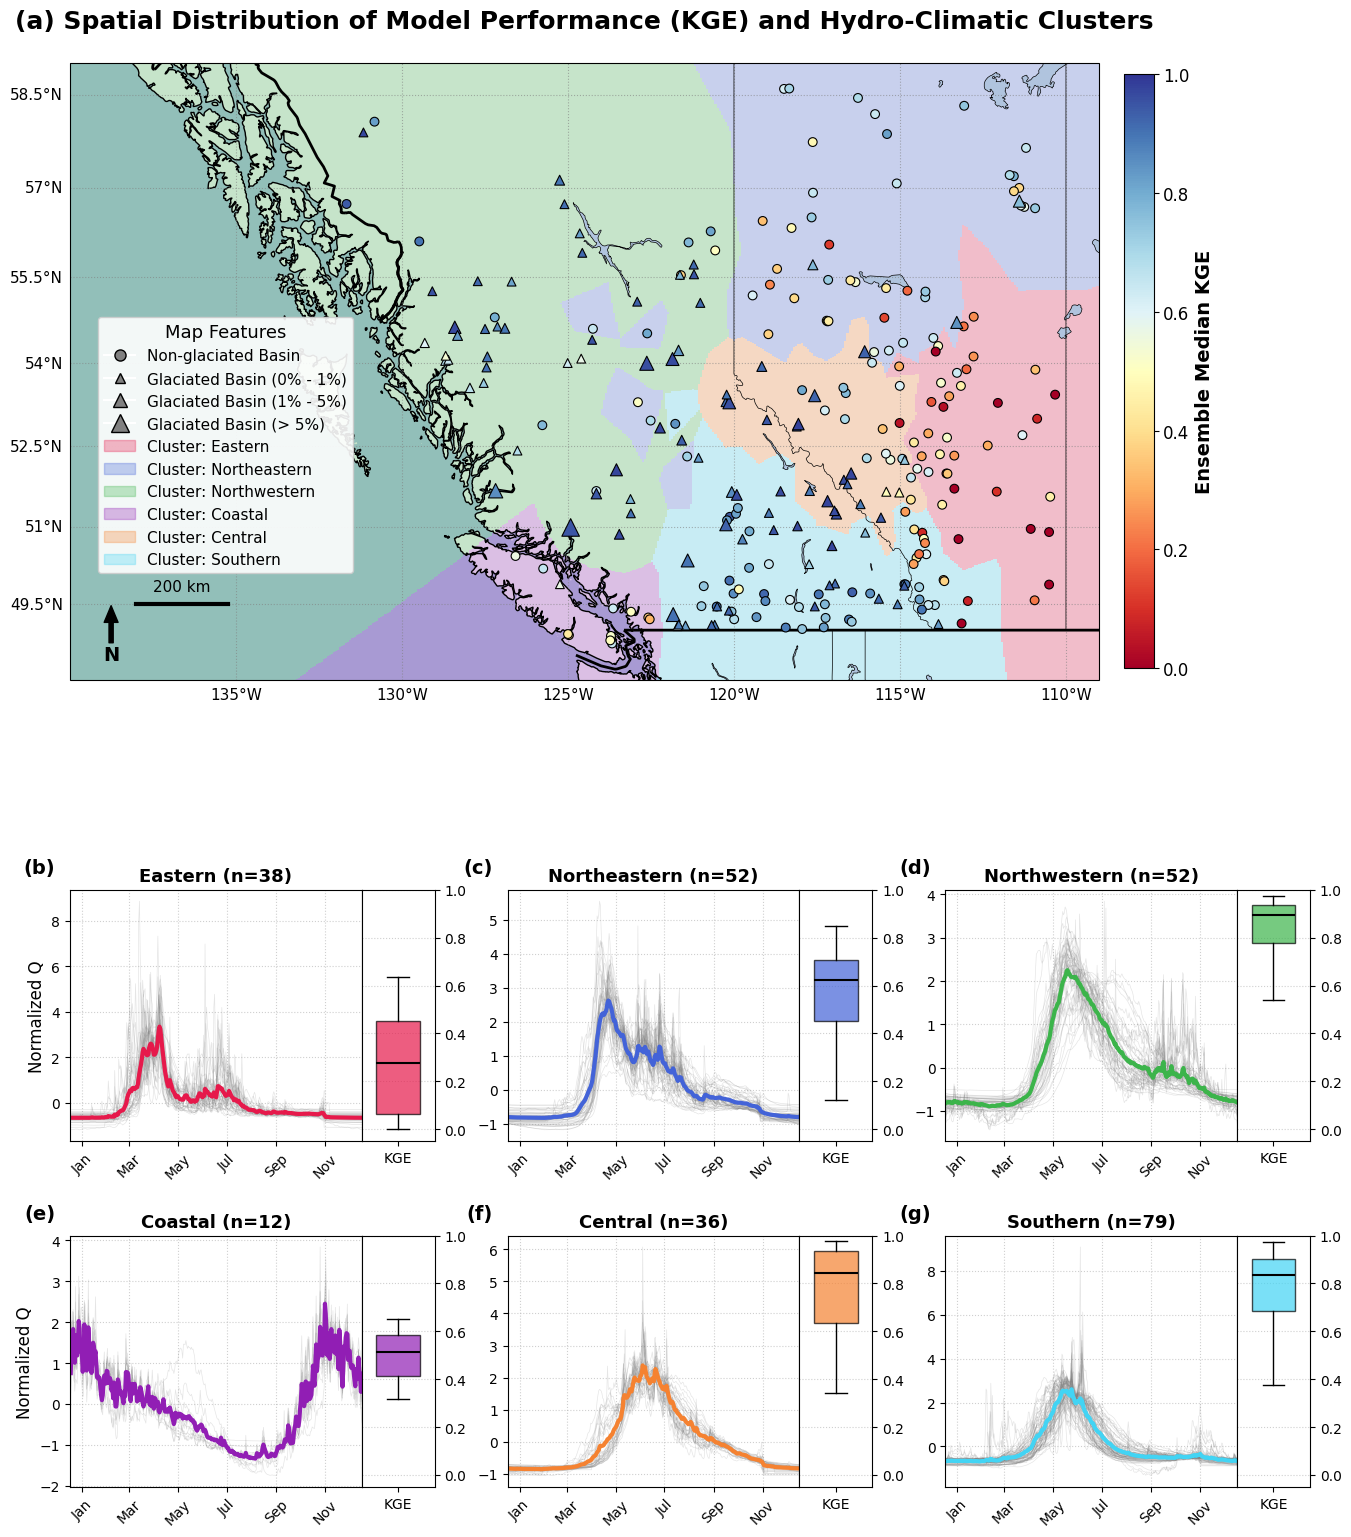

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np
import warnings
from src.config import TEST_START_YEAR, TEST_END_YEAR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Temporal Filtering for KGE (Test Period Only)
# =========================================================
df_obs_test = df_obs[(df_obs.index.year >= TEST_START_YEAR) & (df_obs.index.year <= TEST_END_YEAR)]
df_pred_test = df_pred[(df_pred.index.year >= TEST_START_YEAR) & (df_pred.index.year <= TEST_END_YEAR)]

# =========================================================
# 2. Imputation for Hydrographs (Using ENTIRE Dataset)
# =========================================================
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble Mean (No Interpolation)
# =========================================================
print("Calculating KGE values on test set...")
all_stations = df_obs.columns
station_median_kge = {}

for stat in all_stations:
    if stat in df_pred_test.columns:
        obs_vals = df_obs_test[stat].values
        sim_vals = df_pred_test[stat].values
        stat_kge = kge(obs_vals, sim_vals)
        station_median_kge[stat] = np.clip(stat_kge, 0, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])
glacier_col = [c for c in df_attr.columns if 'glac' in c.lower()][0]

# =========================================================
# 4. Clustering (Using Hydrographs + Spatial Coordinates)
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_attr[['latitude', 'longitude']], how='inner')

hydro_features = X_merged.drop(columns=['latitude', 'longitude']).values
lat_norm = (X_merged['latitude'] - X_merged['latitude'].mean()) / X_merged['latitude'].std()
lon_norm = (X_merged['longitude'] - X_merged['longitude'].mean()) / X_merged['longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_attr[['latitude', 'longitude', glacier_col]], how='inner')
df_plot = df_plot.rename(columns={glacier_col: 'glacier_pct'})
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['longitude', 'latitude']], df_plot['Cluster'])

xx, yy = np.meshgrid(np.linspace(-140, -109, 500), np.linspace(48, 59, 500))
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("\n=========================================")
print("Median KGE by Spatial Cluster:")
print("=========================================")
for cid in range(6):
    med_kge = df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].median()
    count = len(df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].dropna())
    print(f"{cluster_names[cid]:<15} (n={count:<3}): {med_kge:.3f}")
print("=========================================\n")

print("Rendering final plot...")

# Pre-calculate global lower limit for KGE boxplots (ignoring outliers)
global_min_whisker = 1.0
for cid in range(6):
    kge_vals = df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].dropna()
    if not kge_vals.empty:
        q1 = kge_vals.quantile(0.25)
        q3 = kge_vals.quantile(0.75)
        iqr = q3 - q1
        lower_whisker = max(kge_vals.min(), q1 - 1.5 * iqr)
        global_min_whisker = min(global_min_whisker, lower_whisker)

y_lower_bound = global_min_whisker - 0.05

fig = plt.figure(figsize=(16, 20))
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.3, wspace=0.2)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=2)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightsteelblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

### NEW: Geographic Coordinates (Graticule) ###
gl = ax_map.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), color='gray', linestyle=':', alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11, 'color': 'black'}
gl.ylabel_style = {'size': 11, 'color': 'black'}

# Plot Voronoi Shading
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot Heatmap Points (Non-glaciated)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=40, marker='o', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5
)

# Plot Heatmap Points (Glaciated) scaled dynamically 
max_glacier = df_plot['glacier_pct'].max() if df_plot['glacier_pct'].max() > 0 else 1
glac_sizes = 40 + (df_plot[df_plot['glacier_pct'] > 0]['glacier_pct'] / max_glacier) * 120

sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=glac_sizes, 
    marker='^', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=6
)

cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Ensemble Median KGE', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

### NEW: North Arrow & Scale Bar ###
# North Arrow pinned to bottom left
ax_map.annotate('N', xy=(0.04, 0.12), xytext=(0.04, 0.04), xycoords='axes fraction',
                fontsize=14, ha='center', va='center', weight='bold',
                arrowprops=dict(facecolor='black', width=3, headwidth=10))

# Scale Bar (Calculated for 49 degrees N latitude: 1 degree lon ≈ 72.8 km. 200km ≈ 2.75 deg)
scale_lon_start = -138
scale_lon_end = -135.25
scale_lat = 49.5
ax_map.plot([scale_lon_start, scale_lon_end], [scale_lat, scale_lat], color='k', linewidth=3, transform=ccrs.PlateCarree(), zorder=10)
ax_map.text((scale_lon_start + scale_lon_end)/2, scale_lat + 0.2, '200 km', transform=ccrs.PlateCarree(), fontsize=11, ha='center', va='bottom', zorder=10)

### NEW: Clarified Legend ###
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated Basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=7, markeredgecolor='k', label='Glaciated Basin (0% - 1%)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated Basin (1% - 5%)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=13, markeredgecolor='k', label='Glaciated Basin (> 5%)')
]
for i in range(6):
    legend_elements.append(mpatches.Patch(color=cluster_colors[i], alpha=0.3, label=f'Cluster: {cluster_names[i]}'))

ax_map.legend(handles=legend_elements, loc='lower left', title="Map Features", fontsize=11, title_fontsize=13, framealpha=0.9, bbox_to_anchor=(0.02, 0.16))
ax_map.set_title('(a) Spatial Distribution of Model Performance (KGE) and Hydro-Climatic Clusters', fontsize=18, fontweight='bold', pad=25)

# --- PANEL B-G: The Hydrographs and KGE Boxplots ---
month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    
    inner_gs = gs[row, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.0)
    
    ax_hydro = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])
    
    ### NEW: Subplot Panel Lettering (b) through (g) ###
    panel_letter = chr(98 + cluster_id)  # 98 is 'b' in ASCII
    ax_hydro.text(-0.05, 1.05, f'({panel_letter})', transform=ax_hydro.transAxes, fontsize=14, fontweight='bold', va='bottom', ha='right')

    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    cluster_kge = df_plot.loc[station_names, 'KGE'].dropna()
    
    # -- 1. Plot Hydrograph --
    ax_hydro.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax_hydro.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=3)
    
    ax_hydro.set_title(f"{cluster_names[cluster_id]} (n={len(station_names)})", fontsize=13, fontweight='bold')
    ax_hydro.set_xticks(month_ticks)
    ax_hydro.set_xticklabels(month_labels, rotation=45)
    ax_hydro.set_xlim(0, 365)
    ax_hydro.grid(True, linestyle=':', alpha=0.6)
    
    if col == 0:
        ax_hydro.set_ylabel('Normalized Q', fontsize=12)
        
    # -- 2. Plot Boxplot --
    box = ax_box.boxplot(cluster_kge, showfliers=False, widths=0.6, patch_artist=True)
    
    for patch in box['boxes']:
        patch.set_facecolor(cluster_colors[cluster_id])
        patch.set_alpha(0.7)
    for median in box['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Apply calculated dynamic minimum bound
    ax_box.set_ylim(y_lower_bound, 1)
    ax_box.set_xticks([1])
    ax_box.set_xticklabels(['KGE'], fontsize=10)
    
    # Shift numerical ticks to the right side
    ax_box.yaxis.tick_right()
    ax_box.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax_box.tick_params(axis='y', labelsize=10)

plt.show()

Counterfactual performance demonstration

Extracting data for Station 05DA009...
Calculating DL ensemble predictions and uncertainties...
Generating plots...


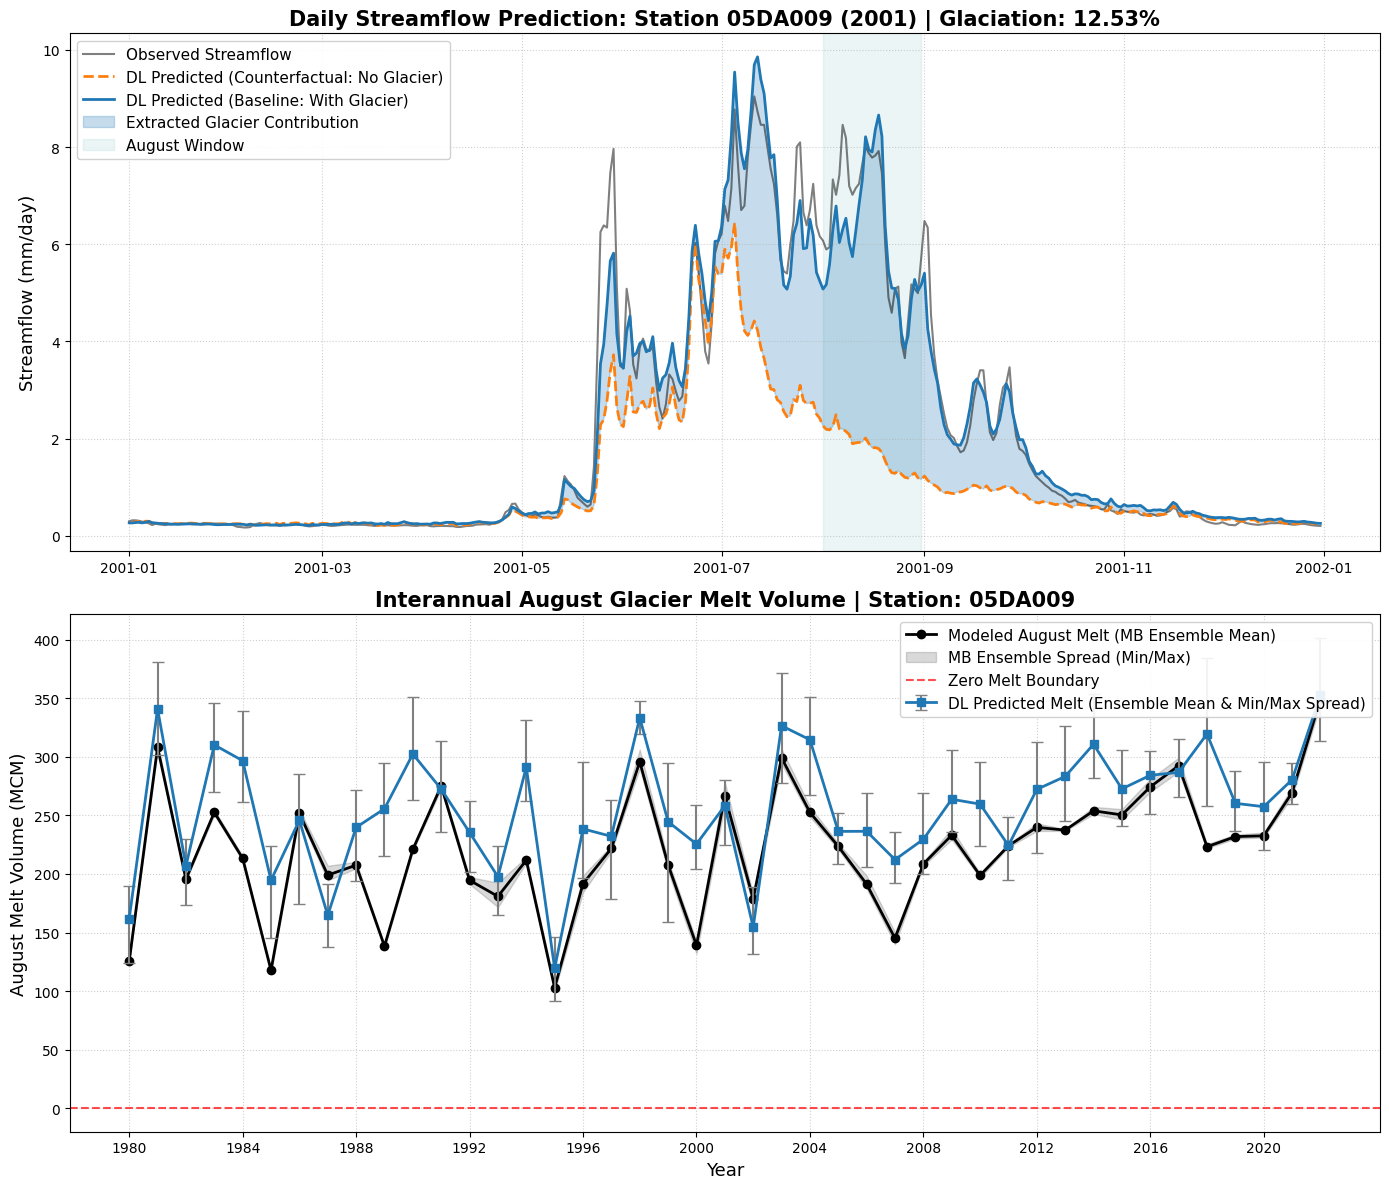

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS
# =========================================================
TARGET_STATION = '05DA009'  # Change to explore different stations
TARGET_YEAR = 2001          # Change to explore different years

# =========================================================
# 2. Extract Target Data from Pre-loaded Environment
# =========================================================
print(f"Extracting data for Station {TARGET_STATION}...")

basin_area = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glac_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Observations are already in mm/day per the environment template
obs_series = df_obs[TARGET_STATION]

# Extract and process the 3-member Mass Balance Ensemble
list_mb_aug_yearly = []
for mb_member in df_mbs:
    # Extract August data, and multiply by -1 to flip sign from mass loss to positive melt
    mb_aug = -mb_member[TARGET_STATION][mb_member.index.month == 8]
    mb_aug_sum = mb_aug.groupby(mb_aug.index.year).sum()
    list_mb_aug_yearly.append(mb_aug_sum)

# Aggregate MB ensemble
df_act_aug_yearly = pd.concat(list_mb_aug_yearly, axis=1)
act_aug_mcm_mean = df_act_aug_yearly.mean(axis=1)

# =========================================================
# 3. Process DL Ensemble Predictions and Uncertainty Spread
# =========================================================
print("Calculating DL ensemble predictions and uncertainties...")

list_aug_mcm_yearly = []

# Iterate through the pre-loaded lists of DL ensemble DataFrames
for pred_member, cf_member in zip(df_preds, df_cf_preds):
    pred = pred_member[TARGET_STATION]
    noglac = cf_member[TARGET_STATION]
    
    # Calculate yearly August MCM for this specific ensemble member
    diff_mm = pred - noglac
    aug_diff_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    # Convert mm over the basin to Million Cubic Meters (MCM)
    aug_mcm = aug_diff_mm * basin_area * 0.001
    list_aug_mcm_yearly.append(aug_mcm)

# Aggregate yearly August melt across the DL ensemble
df_aug_yearly = pd.concat(list_aug_mcm_yearly, axis=1)

# Extract deterministic daily means directly from the pre-computed templates
mean_pred_daily = df_pred[TARGET_STATION]
mean_noglac_daily = df_cf_pred[TARGET_STATION]

# --- Alignment and Uncertainty Calculations ---

# Ensure years align perfectly between DL predictions and MB ground truth
common_years = df_aug_yearly.index.intersection(act_aug_mcm_mean.index)

# 1. Subset DL predictions and calculate bounds
df_aug_yearly = df_aug_yearly.loc[common_years]
mean_aug_mcm = df_aug_yearly.mean(axis=1)
min_aug_mcm = df_aug_yearly.min(axis=1)
max_aug_mcm = df_aug_yearly.max(axis=1)

err_lower = mean_aug_mcm - min_aug_mcm
err_upper = max_aug_mcm - mean_aug_mcm
dl_yerr = [err_lower.values, err_upper.values]

# 2. Subset MB predictions and calculate bounds
df_act_aug_yearly = df_act_aug_yearly.loc[common_years]
act_aug_mcm_mean = act_aug_mcm_mean.loc[common_years]
act_min_aug_mcm = df_act_aug_yearly.min(axis=1)
act_max_aug_mcm = df_act_aug_yearly.max(axis=1)

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# ---------------------------------------------------------
# PANEL 1: Daily Hydrograph with Shaded Glacier Contribution
# ---------------------------------------------------------
year_mask = mean_pred_daily.index.year == TARGET_YEAR
dates_yr = mean_pred_daily[year_mask].index

pred_yr = mean_pred_daily[year_mask]
noglac_yr = mean_noglac_daily[year_mask]
obs_yr = obs_series[year_mask]

ax1.plot(dates_yr, obs_yr, color='black', alpha=0.5, label='Observed Streamflow', linewidth=1.5)
ax1.plot(dates_yr, noglac_yr, color='tab:orange', linestyle='--', label='DL Predicted (Counterfactual: No Glacier)', linewidth=2)
ax1.plot(dates_yr, pred_yr, color='tab:blue', label='DL Predicted (Baseline: With Glacier)', linewidth=2)

# Shade the area ONLY where With Glacier > Without Glacier
ax1.fill_between(dates_yr, noglac_yr, pred_yr, where=(pred_yr > noglac_yr), 
                 interpolate=True, color='tab:blue', alpha=0.25, label='Extracted Glacier Contribution')

# Highlight August Window
aug_start = pd.to_datetime(f"{TARGET_YEAR}-08-01")
aug_end = pd.to_datetime(f"{TARGET_YEAR}-08-31")
ax1.axvspan(aug_start, aug_end, color='teal', alpha=0.08, label='August Window')

ax1.set_title(f"Daily Streamflow Prediction: Station {TARGET_STATION} ({TARGET_YEAR}) | Glaciation: {glac_pct:.2f}%", fontsize=15, fontweight='bold')
ax1.set_ylabel("Streamflow (mm/day)", fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# ---------------------------------------------------------
# PANEL 2: Interannual August Melt Time Series w/ Bounds
# ---------------------------------------------------------
years = common_years.values

# Plot the Actual Mass Balance (Ground Truth) with Shaded Uncertainty
ax2.plot(years, act_aug_mcm_mean.values, color='black', marker='o', linestyle='-', linewidth=2, markersize=6, label='Modeled August Melt (MB Ensemble Mean)')
ax2.fill_between(years, act_min_aug_mcm.values, act_max_aug_mcm.values, color='black', alpha=0.15, label='MB Ensemble Spread (Min/Max)')

# Plot the DL Predicted Mean with Ensemble Error Bars
ax2.errorbar(years, mean_aug_mcm.values, yerr=dl_yerr, fmt='s-', color='tab:blue', linewidth=2, capsize=4, 
             ecolor='gray', elinewidth=1.5, markersize=6, label='DL Predicted Melt (Ensemble Mean & Min/Max Spread)')

ax2.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Melt Boundary')

ax2.set_title(f"Interannual August Glacier Melt Volume | Station: {TARGET_STATION}", fontsize=15, fontweight='bold')
ax2.set_ylabel("August Melt Volume (MCM)", fontsize=13)
ax2.set_xlabel("Year", fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fix x-axis ticks to show round years cleanly
ax2.set_xticks(np.arange(min(years), max(years)+1, 4))

plt.tight_layout()
plt.show()

SOM cluster patterns

Extracting data and setting up specific yield...
Building datasets (Climatology Mode: False)...
Running SOM clustering (2x2 grid) on N=3741 samples...
Cluster assignments successfully saved to 'df_som_clusters' in memory.
Generating topological cluster plots...


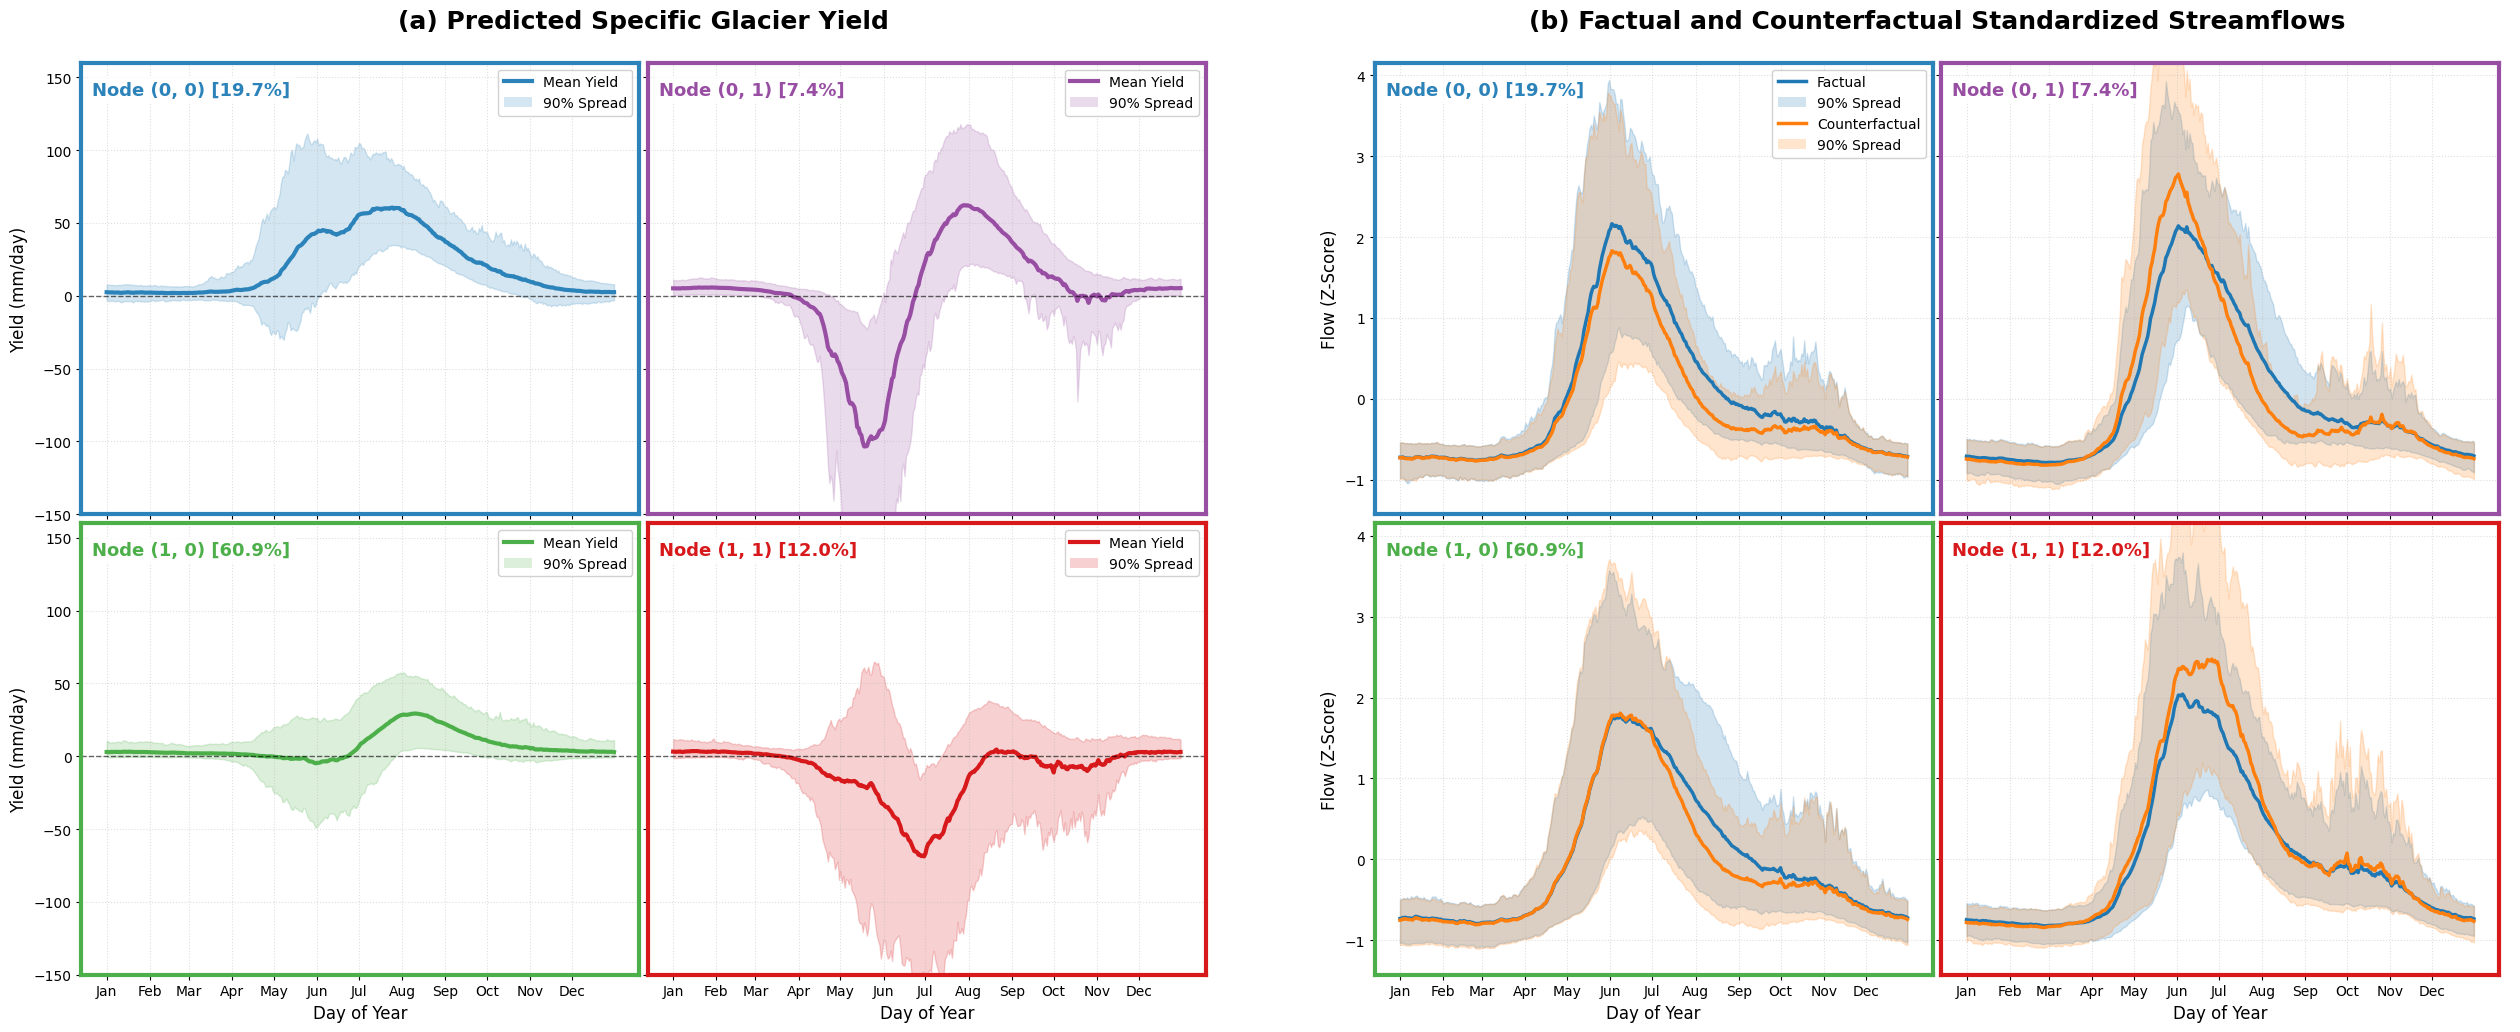

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from minisom import MiniSom
import warnings
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS & TOGGLES
# =========================================================
# Set to True: Cluster on the 43-year average hydrograph for each station (N ~ 87)
# Set to False: Cluster on every individual station-year combination (N ~ 87 * 43)
CLUSTER_CLIMATOLOGY = False

# =========================================================
# 2. Establish Target Variables from Environment
# =========================================================
print("Extracting data and setting up specific yield...")

test_dates = df_pred.index
years = np.unique(test_dates.year)

# =========================================================
# 3. Build Datasets (Applying the Climatology Toggle)
# =========================================================
print(f"Building datasets (Climatology Mode: {CLUSTER_CLIMATOLOGY})...")

X_raw = [] # Specific Glacier Yield (mm/day)
P_raw = [] # Baseline Basin Streamflow (df_pred)
N_raw = [] # Counterfactual Basin Streamflow (df_cf_pred)
metadata = []

if CLUSTER_CLIMATOLOGY:
    # Remove leap days to ensure clean 365-day averaging
    dq_no_leap = dq_pred_mm_glacier[dq_pred_mm_glacier.index.dayofyear != 366]
    p_no_leap = df_pred[glaciated_stations][df_pred.index.dayofyear != 366]
    n_no_leap = df_cf_pred[glaciated_stations][df_cf_pred.index.dayofyear != 366]
    
    # Calculate the climatological mean for each day of the year
    X_clim = dq_no_leap.groupby(dq_no_leap.index.dayofyear).mean()
    P_clim = p_no_leap.groupby(p_no_leap.index.dayofyear).mean()
    N_clim = n_no_leap.groupby(n_no_leap.index.dayofyear).mean()
    
    for stat in glaciated_stations:
        dq_vals = X_clim[stat].values
        p_vals = P_clim[stat].values
        n_vals = N_clim[stat].values
        
        if np.nanmax(dq_vals) > 0.05:
            X_raw.append(dq_vals)
            P_raw.append(p_vals)
            N_raw.append(n_vals)
            metadata.append({'Station': stat, 'Type': 'Climatological Mean'})

else:
    for year in years:
        mask = test_dates.year == year
        
        dq_year = dq_pred_mm_glacier[mask]
        p_year = df_pred[glaciated_stations][mask]
        n_year = df_cf_pred[glaciated_stations][mask]
        
        for stat in glaciated_stations:
            dq_vals = dq_year[stat].values
            p_vals = p_year[stat].values
            n_vals = n_year[stat].values
            
            # Standardize arrays to non-leap year length
            if len(p_vals) == 366:
                dq_vals = dq_vals[:-1]
                p_vals = p_vals[:-1]
                n_vals = n_vals[:-1]
                
            if len(p_vals) == 365:
                if np.nanmax(dq_vals) > 0.05:
                    X_raw.append(dq_vals)
                    P_raw.append(p_vals)
                    N_raw.append(n_vals)
                    metadata.append({'Station': stat, 'Year': year})

X = np.array(X_raw)
P = np.array(P_raw)
N = np.array(N_raw)

# --- STANDARDIZATION ---
P_mean = np.mean(P, axis=1, keepdims=True)
P_std = np.std(P, axis=1, keepdims=True)
P_std[P_std == 0] = 1e-6 

P_scaled = (P - P_mean) / P_std
N_scaled = (N - P_mean) / P_std

X_train = X

# =========================================================
# 4. SOM Clustering
# =========================================================
grid_x, grid_y = 2, 2
k = grid_x * grid_y

print(f"Running SOM clustering ({grid_x}x{grid_y} grid) on N={len(X_train)} samples...")

som = MiniSom(x=grid_x, y=grid_y, input_len=X_train.shape[1], sigma=0.5, learning_rate=0.2, random_seed=42)
som.pca_weights_init(X_train)
som.train_random(X_train, num_iteration=5000)

winner_coords = np.array([som.winner(x) for x in X_train])
labels = winner_coords[:, 0] * grid_y + winner_coords[:, 1]

# =========================================================
# 5. Save Clusters to Dataframe
# =========================================================
df_som_clusters = pd.DataFrame(metadata)
df_som_clusters['Cluster'] = labels
print("Cluster assignments successfully saved to 'df_som_clusters' in memory.")

# =========================================================
# 6. Plotting (Nested GridSpec Layout)
# =========================================================
print("Generating topological cluster plots...")

cluster_colors = {
    3: '#d7191c',  # Red
    0: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    1: '#984ea3'   # Purple
}

fig = plt.figure(figsize=(26, 12))
title_prefix = "Climatological" if CLUSTER_CLIMATOLOGY else "Interannual"
# fig.suptitle(f"SOM Clustering: {title_prefix} Specific Glacier Yield\n(90% Confidence Bounds | Standardized Streamflow Z-Scores)", fontsize=20, fontweight='bold', y=0.98)

# Create an Outer GridSpec to hold the two major 2x2 blocks (with a clear gap between them)
gs_outer = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.15)

# --- ADD INVISIBLE AXES FOR BLOCK TITLES ---
ax_outer_left = fig.add_subplot(gs_outer[0], frameon=False, zorder=-1)
ax_outer_left.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_outer_left.set_title("(a) Predicted Specific Glacier Yield", fontsize=18, fontweight='bold', pad=25)

ax_outer_right = fig.add_subplot(gs_outer[1], frameon=False, zorder=-1)
ax_outer_right.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_outer_right.set_title("(b) Factual and Counterfactual Standardized Streamflows", fontsize=18, fontweight='bold', pad=25)

# Create Inner GridSpecs with a 'micro-gap' (0.015 to 0.02) so the 3pt borders sit perfectly beside each other
gs_left = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_outer[0], wspace=0.015, hspace=0.02)
gs_right = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_outer[1], wspace=0.015, hspace=0.02)

x_days = np.arange(1, 366)
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

yield_ymin = -150
yield_ymax = 160

str_ymin = min(np.percentile(P_scaled, 5), np.percentile(N_scaled, 5)) - 0.5
str_ymax = max(np.percentile(P_scaled, 95), np.percentile(N_scaled, 95)) + 2

total_samples = len(labels)

for i in range(k):
    qx = i // grid_y
    qy = i % grid_y
    
    # Assign subplots to the respective Inner GridSpecs
    ax_diff = fig.add_subplot(gs_left[qx, qy])
    ax_abs  = fig.add_subplot(gs_right[qx, qy])
    
    diff_data = X[labels == i]              
    p_data    = P_scaled[labels == i]       
    n_data    = N_scaled[labels == i]       
    n_samples = len(diff_data)
    
    # Calculate percentage for label
    pct = (n_samples / total_samples) * 100 if total_samples > 0 else 0
    label_text = f"Node ({qx}, {qy}) [{pct:.1f}%]"
    
    c_color = cluster_colors[i]
    
    # --- APPLY CLUSTER-COLORED BORDERS ---
    for ax in [ax_diff, ax_abs]:
        for spine in ax.spines.values():
            spine.set_edgecolor(c_color)
            spine.set_linewidth(3)  # Thick bold border
            spine.set_zorder(10)    # Ensures borders sit on top of the grid lines
    
    if n_samples == 0:
        ax_diff.text(0.5, 0.5, f"Node ({qx}, {qy}) [0.0%]", ha='center', va='center')
        ax_abs.axis('off')
        continue
    
    # --- LEFT SIDE: Specific Glacier Yield (mm/day) ---
    diff_mean = np.mean(diff_data, axis=0)
    diff_lower, diff_upper = np.percentile(diff_data, [5, 95], axis=0)
    
    ax_diff.fill_between(x_days, diff_lower, diff_upper, color=c_color, alpha=0.2)
    ax_diff.plot(x_days, diff_mean, color=c_color, linewidth=3, label='Mean Yield')
    ax_diff.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    
    # Inside Node Label
    ax_diff.text(0.02, 0.96, label_text, transform=ax_diff.transAxes, fontsize=13, fontweight='bold', color=c_color, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=3), va='top', zorder=5)
    
    ax_diff.set_ylim(yield_ymin, yield_ymax)
    ax_diff.set_xticks(month_ticks)
    ax_diff.grid(True, linestyle=':', alpha=0.4)
    
    custom_diff = [Line2D([0], [0], color=c_color, lw=3), Patch(facecolor=c_color, alpha=0.2)]
    ax_diff.legend(custom_diff, ['Mean Yield', '90% Spread'], loc='upper right', framealpha=0.9)
    
    # --- RIGHT SIDE: Standardized Streamflow ---
    p_mean = np.mean(p_data, axis=0)
    n_mean = np.mean(n_data, axis=0)
    p_lower, p_upper = np.percentile(p_data, [5, 95], axis=0)
    n_lower, n_upper = np.percentile(n_data, [5, 95], axis=0)
    
    ax_abs.fill_between(x_days, p_lower, p_upper, color='tab:blue', alpha=0.2)
    ax_abs.plot(x_days, p_mean, color='tab:blue', linewidth=2.5, label='Baseline Mean')
    ax_abs.fill_between(x_days, n_lower, n_upper, color='tab:orange', alpha=0.2)
    ax_abs.plot(x_days, n_mean, color='tab:orange', linewidth=2.5, label='Counterfactual Mean')
    
    # Inside Node Label
    ax_abs.text(0.02, 0.96, label_text, transform=ax_abs.transAxes, fontsize=13, fontweight='bold', color=c_color, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=3), va='top', zorder=5)
    
    ax_abs.set_ylim(str_ymin, str_ymax)
    ax_abs.set_xticks(month_ticks)
    ax_abs.grid(True, linestyle=':', alpha=0.4)
    
    if i == 0: 
        custom_abs = [Line2D([0], [0], color='tab:blue', lw=2.5), Patch(facecolor='tab:blue', alpha=0.2), Line2D([0], [0], color='tab:orange', lw=2.5), Patch(facecolor='tab:orange', alpha=0.2)]
        ax_abs.legend(custom_abs, ['Factual', '90% Spread', 'Counterfactual', '90% Spread'], loc='upper right', framealpha=0.9)

    # --- CONDITIONAL FORMATTING ---
    if qx == 0: 
        ax_diff.tick_params(labelbottom=False)
        ax_abs.tick_params(labelbottom=False)
    else:       
        ax_diff.set_xticklabels(month_labels)
        ax_abs.set_xticklabels(month_labels)
        ax_diff.set_xlabel("Day of Year", fontsize=12)
        ax_abs.set_xlabel("Day of Year", fontsize=12)

    if qy == 0: 
        ax_diff.set_ylabel("Yield (mm/day)", fontsize=12)
        ax_abs.set_ylabel("Flow (Z-Score)", fontsize=12)
    else:       
        ax_diff.tick_params(labelleft=False)
        ax_abs.tick_params(labelleft=False)

# Adjusted top margin to ensure space for the block titles
plt.subplots_adjust(top=0.86, bottom=0.1, left=0.05, right=0.98)
plt.show()

Extracting SOM clusters and metadata from environment variables...
Loading basin boundaries from GeoPackages...
  -> Successfully loaded MDA_ADP_05.gpkg (1740 basins)
  -> Successfully loaded MDA_ADP_07.gpkg (476 basins)
  -> Successfully loaded MDA_ADP_08.gpkg (2180 basins)
Successfully matched and sorted 87 basin polygons.
Fetching geographic boundaries...
Rendering map...


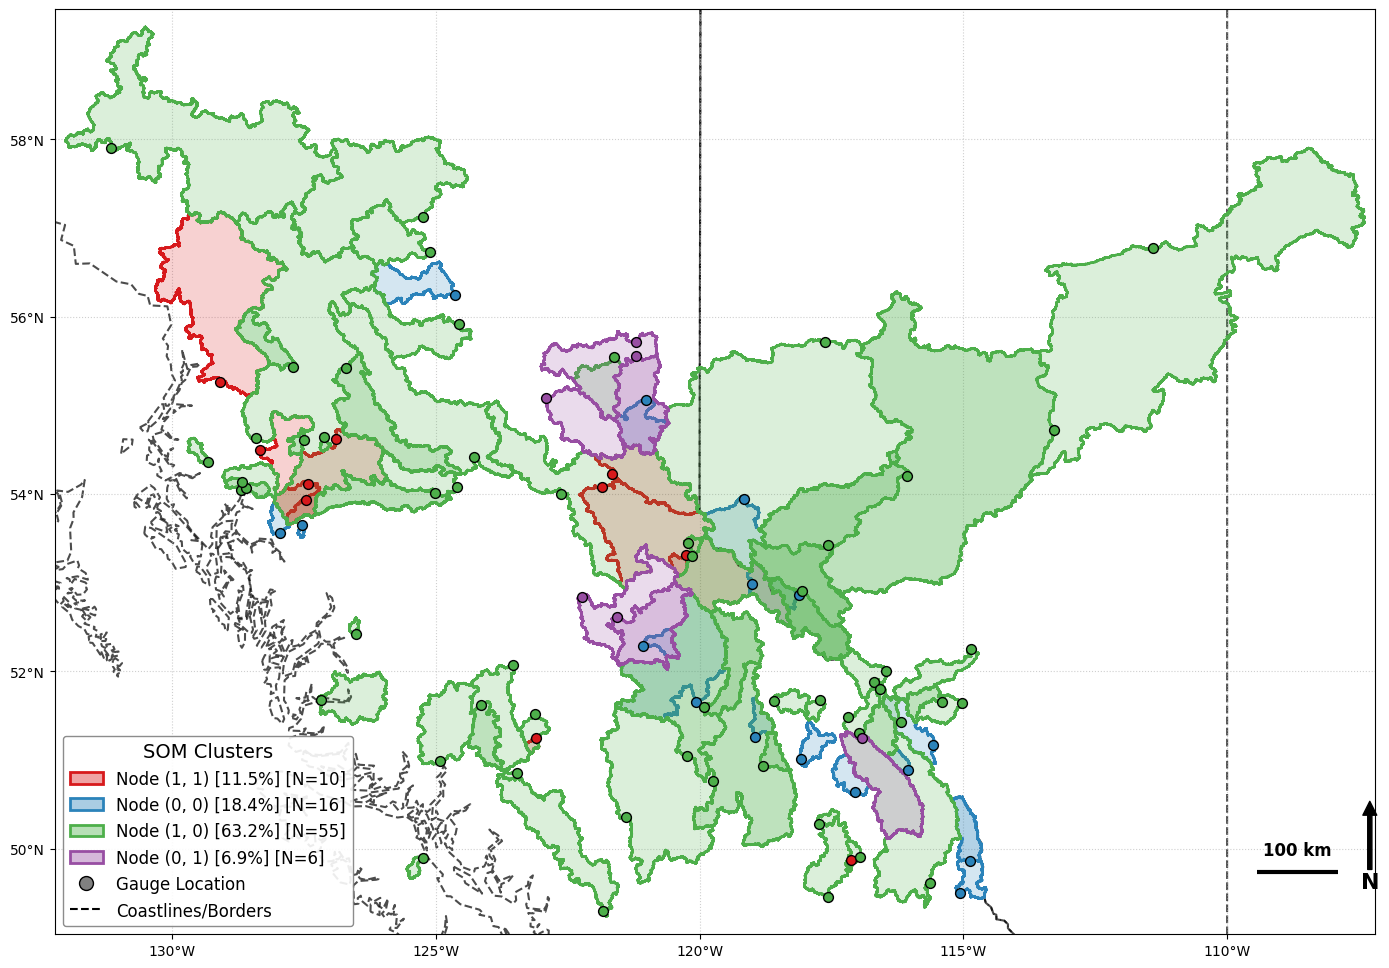

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import warnings
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

from src.config import RAW_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Station Metadata and SOM Clusters
# =========================================================
print("Extracting SOM clusters and metadata from environment variables...")

# Use the in-memory dataframe generated by the clustering script
df_dominant = df_som_clusters.groupby('Station')['Cluster'].agg(lambda x: x.mode()[0]).reset_index()
df_dominant['Station'] = df_dominant['Station'].astype(str).str.strip().str.upper()

# Pull coordinates directly from the pre-loaded attributes dataframe
df_geo = df_attr[['latitude', 'longitude']].copy()
df_geo.index = df_geo.index.astype(str).str.strip().str.upper()
df_geo = df_geo.rename(columns={'latitude': 'Latitude', 'longitude': 'Longitude'})

# Merge to get Lat/Lon points for the clusters
df_map = pd.merge(df_dominant, df_geo, left_on='Station', right_index=True, how='inner')

# Create a GeoDataFrame for the Gauge Points
gdf_points = gpd.GeoDataFrame(
    df_map, 
    geometry=gpd.points_from_xy(df_map['Longitude'], df_map['Latitude']),
    crs="EPSG:4326"
)

# =========================================================
# 2. Load and Combine Basin Geometries (GeoPackages)
# =========================================================
print("Loading basin boundaries from GeoPackages...")

gpkg_files = ["MDA_ADP_05.gpkg", "MDA_ADP_07.gpkg", "MDA_ADP_08.gpkg"]
gdfs = []

for file_name in gpkg_files:
    file_path = RAW_DATA_DIR / "drainage_areas" / file_name
    try:
        gdf_part = gpd.read_file(file_path)
        gdfs.append(gdf_part)
        print(f"  -> Successfully loaded {file_name} ({len(gdf_part)} basins)")
    except Exception as e:
        print(f"  -> ⚠️ Failed to load {file_name}: {e}")

if not gdfs:
    raise FileNotFoundError("Could not load any basin geometries. Please check the file paths.")

gdf_basins = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

possible_cols = ['station_id', 'station', 'id', 'station_number', 'stationnum']
station_col = next((c for c in gdf_basins.columns if c.lower() in possible_cols), None)

if station_col:
    gdf_basins[station_col] = gdf_basins[station_col].astype(str).str.strip().str.upper()
else:
    raise ValueError("Could not find a station ID column in your basin shapefiles.")

# Merge the polygons with the cluster assignments
gdf_cluster_basins = gdf_basins.merge(df_map, left_on=station_col, right_on='Station', how='inner')

# --- Calculate area and sort so smallest basins plot on top ---
# We temporarily project to a meter-based CRS (Web Mercator) to get an accurate area metric
gdf_cluster_basins['calc_area'] = gdf_cluster_basins.to_crs("EPSG:3857").geometry.area
gdf_cluster_basins = gdf_cluster_basins.sort_values(by='calc_area', ascending=False)

# Reproject to WGS 84 (Degrees) for the final plot
gdf_cluster_basins = gdf_cluster_basins.to_crs("EPSG:4326")
print(f"Successfully matched and sorted {len(gdf_cluster_basins)} basin polygons.")

# =========================================================
# 3. Fetch Province Boundaries (BC and Alberta)
# =========================================================
print("Fetching geographic boundaries...")
try:
    url_provinces = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
    canada = gpd.read_file(url_provinces)
    bc_ab = canada[canada['name'].isin(['British Columbia', 'Alberta'])]
    bc_ab = bc_ab.to_crs("EPSG:4326")
except Exception as e:
    print(f"⚠️ Could not load province boundaries from web: {e}")
    bc_ab = None

# =========================================================
# 4. Plotting
# =========================================================
print("Rendering map...")

fig, ax = plt.subplots(figsize=(14, 12))

# Fix the Geographic Aspect Ratio (Pseudo-Mercator correction for ~54 Degrees North)
map_aspect_ratio = 1.0 / np.cos(np.radians(54))
ax.set_aspect(map_aspect_ratio)

# Plot Provinces (Background Context)
if bc_ab is not None:
    bc_ab.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', alpha=0.7, zorder=1)

cluster_colors = {
    3: '#d7191c',  # Red
    0: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    1: '#984ea3'   # Purple
}

legend_elements = []
total_samples = len(gdf_cluster_basins)

# Plot Basins and Gauge Points per cluster
for cluster_id, color in cluster_colors.items():
    qx = cluster_id // 2
    qy = cluster_id % 2
    label_text = f'Node ({qx}, {qy})'
    
    subset_poly = gdf_cluster_basins[gdf_cluster_basins['Cluster'] == cluster_id]
    n_samples = len(subset_poly)
    pct = (n_samples / total_samples) * 100 if total_samples > 0 else 0
    
    if not subset_poly.empty:
        # Faint face color, prominent solid edge color
        fill_color = mcolors.to_rgba(color, alpha=0.20)
        
        subset_poly.plot(
            ax=ax, 
            facecolor=fill_color, 
            edgecolor=color,     
            linewidth=1.8,       
            zorder=2
        )
        
    subset_pts = gdf_points[gdf_points['Cluster'] == cluster_id]
    if not subset_pts.empty:
        subset_pts.plot(
            ax=ax, 
            color=color, 
            markersize=50,       
            edgecolor='black',   
            linewidth=1.0, 
            zorder=3
        )
        
        legend_elements.append(
            Patch(facecolor=mcolors.to_rgba(color, alpha=0.4), edgecolor=color, linewidth=2, label=f"{label_text} [{pct:.1f}%] [N={n_samples}]")
        )

# Legend Formatting
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='black', label='Gauge Location'))
legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Coastlines/Borders'))


# Formatting
ax.set_xlabel("")
ax.set_ylabel("")

def format_lon(value, tick_number):
    return f"{abs(value):g}°W" if value < 0 else f"{value:g}°E"

def format_lat(value, tick_number):
    return f"{value:g}°N" if value > 0 else f"{abs(value):g}°S"

ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
ax.yaxis.set_major_formatter(FuncFormatter(format_lat))


if not gdf_cluster_basins.empty:
    minx, miny, maxx, maxy = gdf_cluster_basins.total_bounds
    # Tighter padding for a better zoom level
    ax.set_xlim(minx - 0.2, maxx + 0.2)
    ax.set_ylim(miny - 0.2, maxy + 0.2)
    
    # Dynamic Scale Bar (100km) and North Arrow
    center_lat = (miny + maxy) / 2
    km_per_deg_lon = 111.32 * np.cos(np.radians(center_lat))
    scale_length_deg = 100 / km_per_deg_lon
    
    # Position in the bottom right corner
    sb_x = maxx - 0.5 - scale_length_deg
    sb_y = miny + 0.5
    
    # Draw Scale Bar
    ax.plot([sb_x, sb_x + scale_length_deg], [sb_y, sb_y], color='black', linewidth=3, solid_capstyle='butt', zorder=10)
    ax.text(sb_x + scale_length_deg/2, sb_y + 0.15, '100 km', ha='center', va='bottom', fontsize=12, fontweight='bold', zorder=10)
    
    # Draw North Arrow
    na_x = sb_x + scale_length_deg + 0.6
    na_y_base = sb_y
    na_y_top = sb_y + 0.8
    ax.annotate('N', xy=(na_x, na_y_top), xytext=(na_x, na_y_base),
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=10),
                ha='center', va='top', fontsize=16, fontweight='bold', zorder=10)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(handles=legend_elements, title="SOM Clusters", loc='lower left', fontsize=12, title_fontsize=14, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.show()

Correlations and evaluation metrics

Extracting mean and bounds for August...
Converting units across all ensemble bounds...
Assembling plotting dataset...
Calculating per-station correlations with 90% Fisher Z-bounds...
Generating Scatter Grid...


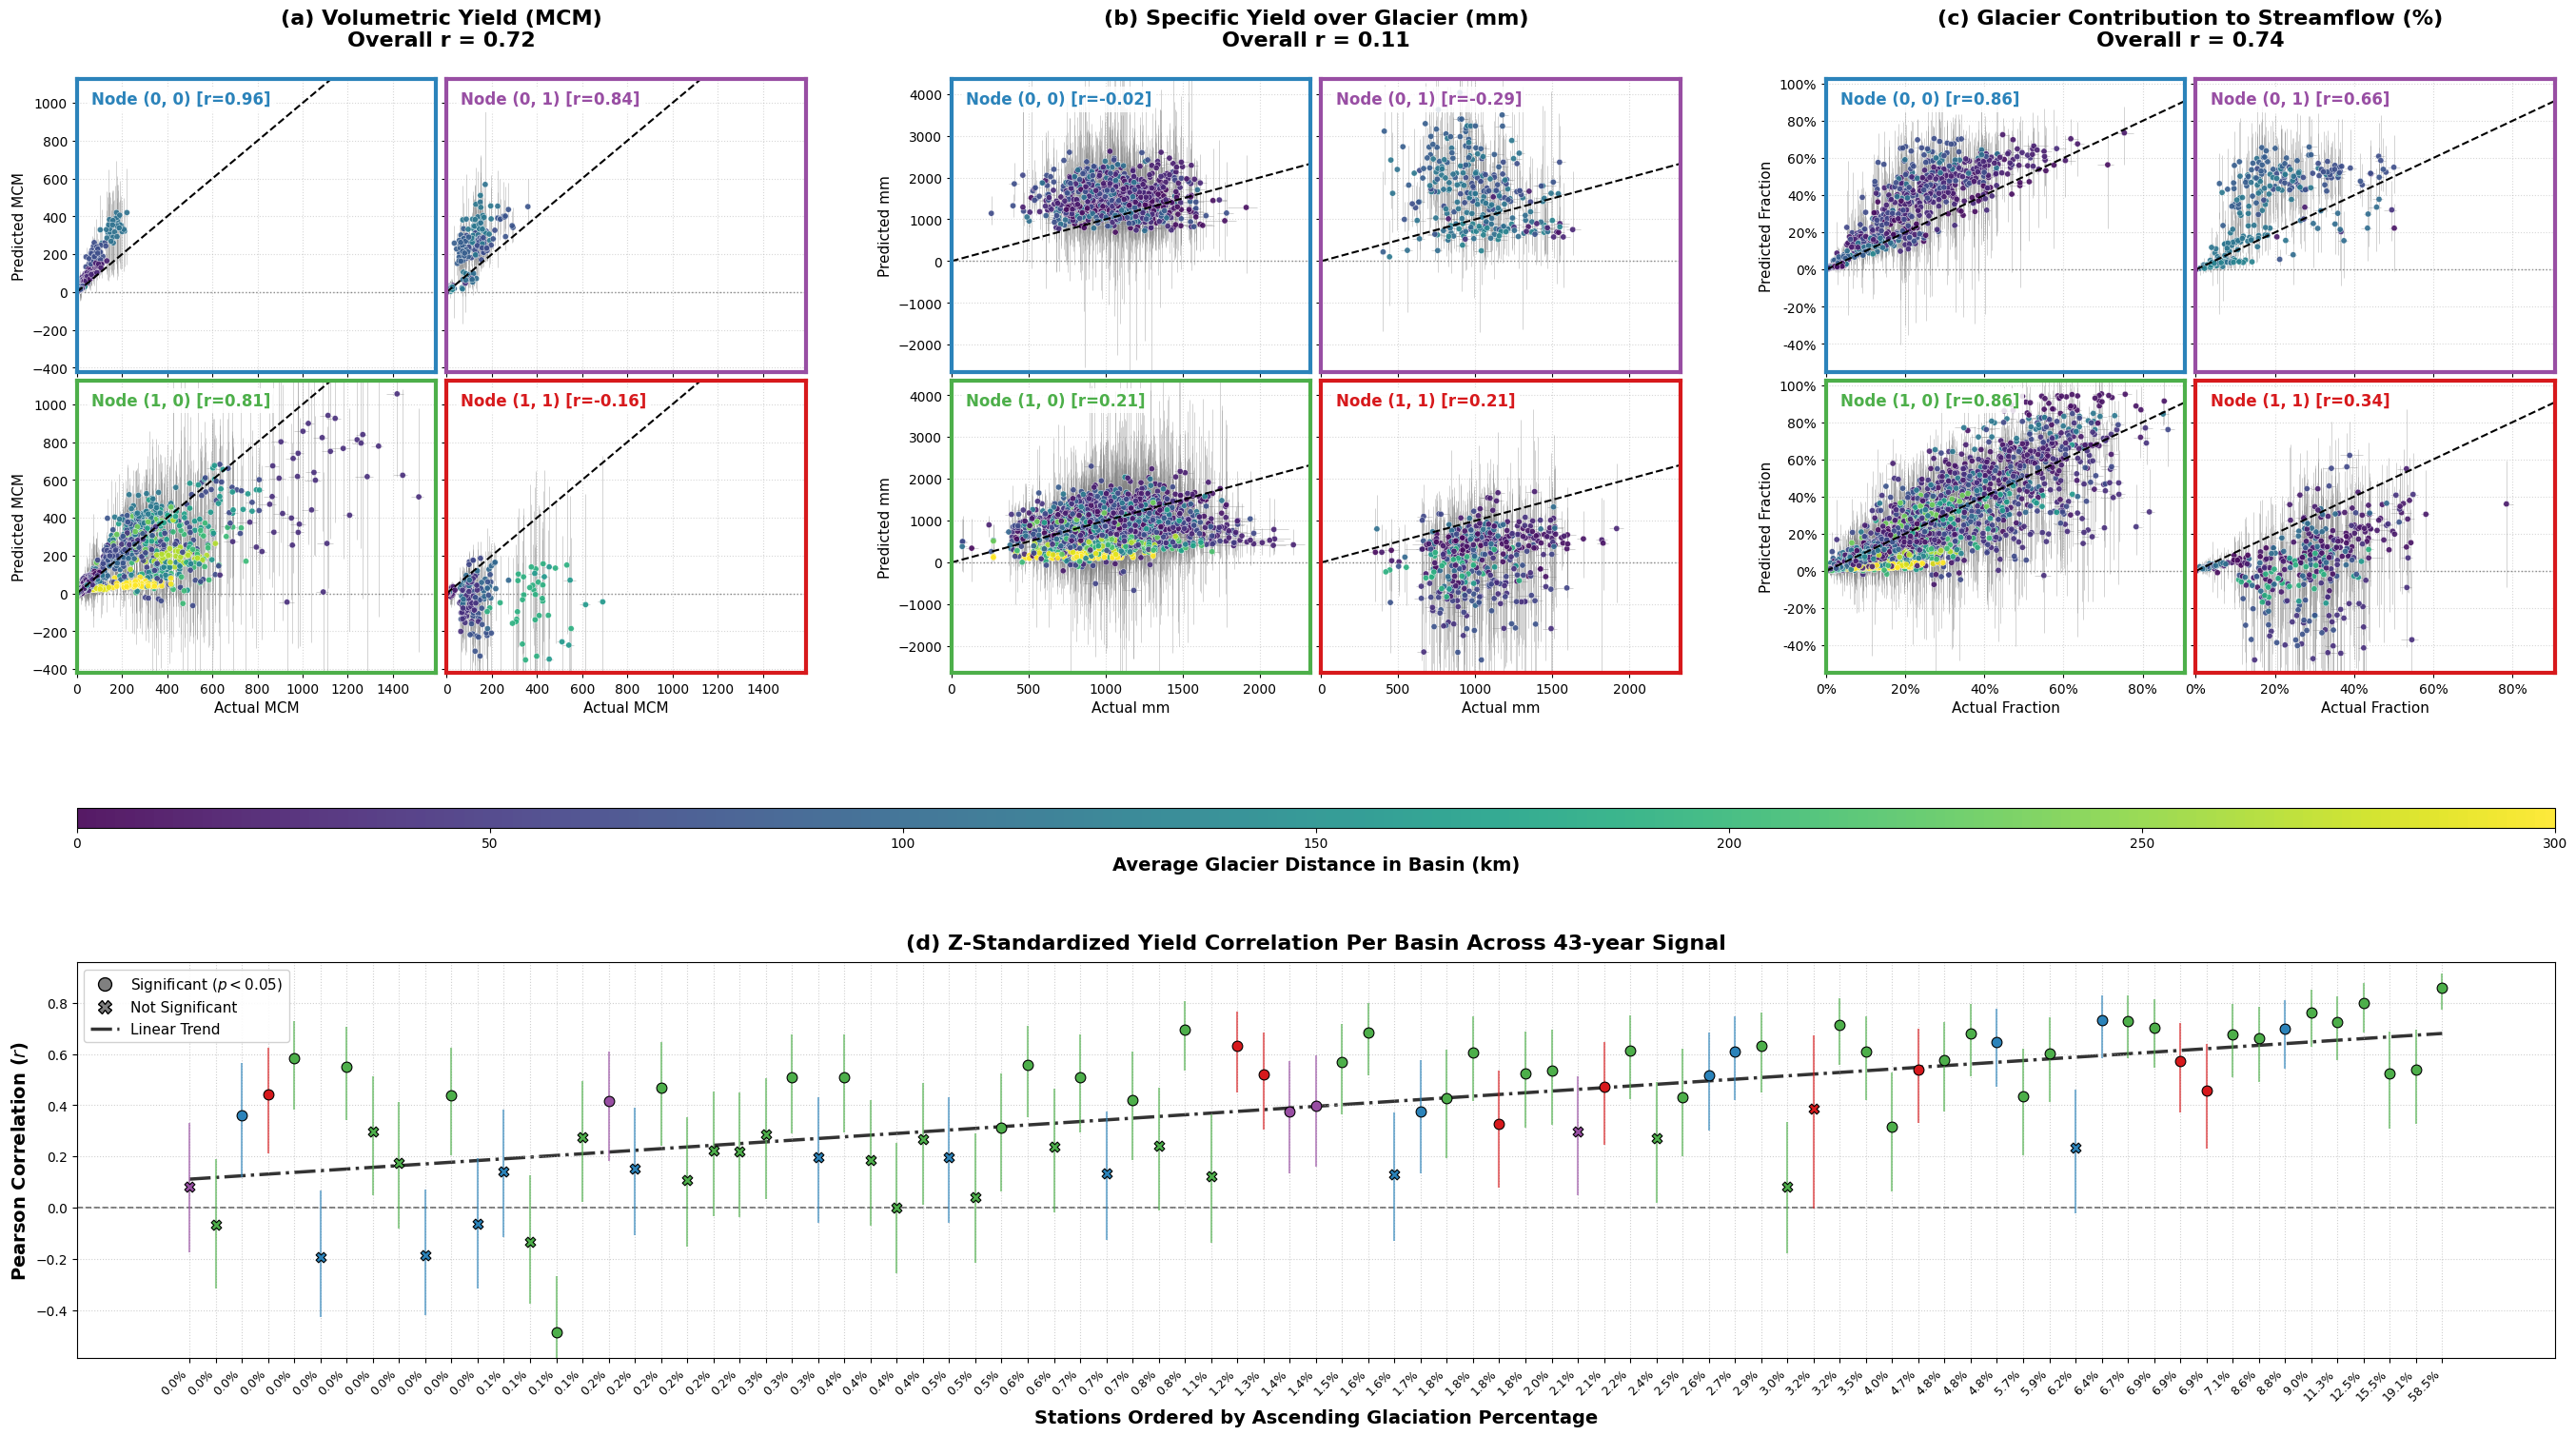

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, norm
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

MONTH = 8 # August

# =========================================================
# 1. Isolate August Data & Extract Range Bounds
# =========================================================
print("Extracting mean and bounds for August...")

aug_mask_daily = (dq_pred.index.month == MONTH)
aug_mask_monthly = (mb_pred.index.month == MONTH)

# Extract Mean
dq_pred_aug_sum = dq_pred[aug_mask_daily].groupby(dq_pred[aug_mask_daily].index.year).sum()
mb_pred_mcm_aug_sum = mb_pred[aug_mask_monthly].groupby(mb_pred[aug_mask_monthly].index.year).sum()

# Extract Min/Max from the provided range variables
dq_min = dq_pred_range.xs('min', level=1, axis=1)
dq_max = dq_pred_range.xs('max', level=1, axis=1)
mb_min = mb_pred_range.xs('min', level=1, axis=1)
mb_max = mb_pred_range.xs('max', level=1, axis=1)

dq_min_aug_sum = dq_min[aug_mask_daily].groupby(dq_min[aug_mask_daily].index.year).sum()
dq_max_aug_sum = dq_max[aug_mask_daily].groupby(dq_max[aug_mask_daily].index.year).sum()
mb_min_aug_sum = mb_min[aug_mask_monthly].groupby(mb_min[aug_mask_monthly].index.year).sum()
mb_max_aug_sum = mb_max[aug_mask_monthly].groupby(mb_max[aug_mask_monthly].index.year).sum()

# =========================================================
# 2. Convert Units (Mean, Min, Max)
# =========================================================
print("Converting units across all ensemble bounds...")

# --- Predicted Metric 1: MCM ---
areas = df_attr.loc[dq_pred_aug_sum.columns, 'basin_area_km2']
dq_pred_mcm_aug_sum = dq_pred_aug_sum * areas * 0.001
dq_min_mcm = dq_min_aug_sum * areas * 0.001
dq_max_mcm = dq_max_aug_sum * areas * 0.001

# --- Predicted Metric 2: mm ---
glac_areas = df_attr.loc[dq_pred_mcm_aug_sum.columns, 'glacier_area_km2']
dq_pred_mm_glacier_aug_sum = dq_pred_mcm_aug_sum * 1000.0 / glac_areas
dq_min_mm = dq_min_mcm * 1000.0 / glac_areas
dq_max_mm = dq_max_mcm * 1000.0 / glac_areas

# --- Predicted Metric 3: Percentage ---
df_pred_glac = df_pred[glaciated_stations]
pred_q_aug = df_pred_glac[aug_mask_daily].groupby(df_pred_glac[aug_mask_daily].index.year).sum()
dq_pred_frac_aug_sum = dq_pred_aug_sum / pred_q_aug
dq_min_pct = dq_min_aug_sum / pred_q_aug
dq_max_pct = dq_max_aug_sum / pred_q_aug

# --- Ground Truth Conversions (Flipping Sign) ---
# Because MB is negative (mass loss), the 'min' value is the most negative (highest positive melt)
act_mcm = -mb_pred_mcm_aug_sum
act_mcm_min = -mb_max_aug_sum # Smallest positive melt
act_mcm_max = -mb_min_aug_sum # Largest positive melt

act_mm = act_mcm * 1000.0 / glac_areas
act_mm_min = act_mcm_min * 1000.0 / glac_areas
act_mm_max = act_mcm_max * 1000.0 / glac_areas

q_obs_aug_sum = q_obs_filtered[aug_mask_daily].groupby(q_obs_filtered[aug_mask_daily].index.year).sum()
q_obs_vol = q_obs_aug_sum * df_attr.loc[q_obs_aug_sum.columns, 'basin_area_km2'] * 0.001

act_pct = act_mcm / q_obs_vol
act_pct_min = act_mcm_min / q_obs_vol
act_pct_max = act_mcm_max / q_obs_vol

# =========================================================
# 3. Stack Data for Plotting
# =========================================================
print("Assembling plotting dataset...")

def stack_metric(df, name):
    stacked = df.stack().reset_index()
    stacked.columns = ['Year', 'Station', name]
    return stacked.set_index(['Year', 'Station'])

plot_df = pd.concat([
    stack_metric(dq_pred_mcm_aug_sum, 'Pred_MCM'),
    stack_metric(dq_min_mcm, 'Pred_MCM_min'),
    stack_metric(dq_max_mcm, 'Pred_MCM_max'),
    
    stack_metric(act_mcm, 'Act_MCM'),
    stack_metric(act_mcm_min, 'Act_MCM_min'),
    stack_metric(act_mcm_max, 'Act_MCM_max'),
    
    stack_metric(dq_pred_mm_glacier_aug_sum, 'Pred_mm'),
    stack_metric(dq_min_mm, 'Pred_mm_min'),
    stack_metric(dq_max_mm, 'Pred_mm_max'),
    
    stack_metric(act_mm, 'Act_mm'),
    stack_metric(act_mm_min, 'Act_mm_min'),
    stack_metric(act_mm_max, 'Act_mm_max'),
    
    stack_metric(dq_pred_frac_aug_sum, 'Pred_Pct'),
    stack_metric(dq_min_pct, 'Pred_Pct_min'),
    stack_metric(dq_max_pct, 'Pred_Pct_max'),
    
    stack_metric(act_pct, 'Act_Pct'),
    stack_metric(act_pct_min, 'Act_Pct_min'),
    stack_metric(act_pct_max, 'Act_Pct_max')
], axis=1).reset_index()

# Merge SOM Clusters & Distance
df_som_clusters['Station'] = df_som_clusters['Station'].astype(str).str.strip().str.upper()

plot_df = pd.merge(plot_df, df_som_clusters[['Year', 'Station', 'Cluster']], on=['Year', 'Station'], how='inner')
plot_df = pd.merge(plot_df, df_attr[['avg_glacier_dist_km']], left_on='Station', right_index=True, how='inner')

# Clean up infinite/wild outliers for plot readability
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
plot_df = plot_df[(plot_df['Pred_Pct'] >= -0.5) & (plot_df['Pred_Pct'] <= 1.5)]
plot_df = plot_df[(plot_df['Act_Pct'] >= -0.5) & (plot_df['Act_Pct'] <= 1.5)]

# =========================================================
# 4. Station-by-Station Standardized Correlations w/ CIs
# =========================================================
print("Calculating per-station correlations with 90% Fisher Z-bounds...")
station_corrs = []

# Z-critical value for 90% confidence interval (two-tailed)
z_crit = norm.ppf(0.95)

for stat in plot_df['Station'].unique():
    stat_data = plot_df[plot_df['Station'] == stat]
    n = len(stat_data)
    
    if n < 4: 
        continue # Need at least N=4 for stable variance and CI calculations
        
    pred = stat_data['Pred_MCM'].values
    act = stat_data['Act_MCM'].values
    
    if np.std(pred) == 0 or np.std(act) == 0:
        continue
        
    z_pred = (pred - np.mean(pred)) / np.std(pred)
    z_act = (act - np.mean(act)) / np.std(act)
    
    r_val, p_val = pearsonr(z_pred, z_act)
    
    # Apply Fisher Z-Transformation to calculate accurate asymmetric confidence intervals
    r_clip = np.clip(r_val, -0.999, 0.999) # Prevent infinity
    z = np.arctanh(r_clip)
    se = 1.0 / np.sqrt(n - 3)
    ci_lower = np.tanh(z - z_crit * se)
    ci_upper = np.tanh(z + z_crit * se)
    
    station_corrs.append({
        'Station': stat,
        'Glacier_Pct': df_attr.loc[stat, 'glacier_pct'],
        'r': r_val,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'Significant': p_val < 0.05,
        'Cluster': stat_data['Cluster'].iloc[0]
    })

df_station_corrs = pd.DataFrame(station_corrs).sort_values(by='Glacier_Pct').reset_index(drop=True)

# =========================================================
# 5. Plotting: The Nested 2x6 Evaluation Grid + Correlation Plot
# =========================================================
print("Generating Scatter Grid...")

fig = plt.figure(figsize=(28, 16))

# --- MASTER GRID SPEC ---
# 3 Rows: [0] Top 2x6 Grids, [1] Thin Colorbar, [2] Bottom Correlation Plot
gs_master = gridspec.GridSpec(3, 1, height_ratios=[1.5, 0.05, 1.0], hspace=0.4)

# Split the top row into 3 columns (one for each metric)
gs_metrics = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_master[0], wspace=0.2)

cluster_colors = {
    3: '#d7191c',  # Red
    0: '#2b83ba',  # Blue
    2: '#4daf4a',  # Green
    1: '#984ea3'   # Purple
}

plot_configs = [
    ('Pred_MCM', 'Act_MCM', '(a) Volumetric Yield (MCM)', 'MCM'),
    ('Pred_mm', 'Act_mm', '(b) Specific Yield over Glacier (mm)', 'mm'),
    ('Pred_Pct', 'Act_Pct', '(c) Glacier Contribution to Streamflow (%)', 'Fraction')
]

vmax_dist = 300 
scatter_ref = None # Will store one scatter object to link to the colorbar

for col_idx, config in enumerate(plot_configs):
    y_col, x_col, title, unit = config
    
    # 1. Create an invisible axis to act as a bounding box for the block title
    ax_title = fig.add_subplot(gs_metrics[col_idx], frameon=False, zorder=-1)
    ax_title.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    
    overall_corr = plot_df[x_col].corr(plot_df[y_col])
    ax_title.set_title(f"{title}\nOverall r = {overall_corr:.2f}", fontsize=16, fontweight='bold', pad=25)
    
    # 2. Create the inner 2x2 grid with tight spacing (micro-gaps)
    gs_inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_metrics[col_idx], wspace=0.03, hspace=0.03)
    
    # Pre-calculate global data bounds for this metric to enforce consistent axes
    x_max = plot_df[x_col].max()
    y_min, y_max = plot_df[y_col].min(), plot_df[y_col].max()
    y_margin = (y_max - y_min) * 0.05
    global_max = max(x_max, y_max)
    
    for cluster_id in range(4):
        qx = cluster_id // 2
        qy = cluster_id % 2
        
        ax = fig.add_subplot(gs_inner[qx, qy])
        subset = plot_df[plot_df['Cluster'] == cluster_id]
        c_color = cluster_colors[cluster_id]
        
        # --- APPLY CLUSTER-COLORED BORDERS ---
        for spine in ax.spines.values():
            spine.set_edgecolor(c_color)
            spine.set_linewidth(3)
            spine.set_zorder(10)
            
        if len(subset) == 0:
            ax.text(0.5, 0.5, f"Node ({qx}, {qy}) - Empty", ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
            
        r_val = subset[x_col].corr(subset[y_col]) if len(subset) > 1 else np.nan
        label = f'Node ({qx}, {qy}) [r={r_val:.2f}]' if not np.isnan(r_val) else f'Node ({qx}, {qy}) [N=1]'
        
        # Add inside title box
        ax.text(0.04, 0.96, label, transform=ax.transAxes, fontsize=12, fontweight='bold', color=c_color, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=3), va='top', zorder=5)
        
        # Error Bars (Neutral Gray so they don't clash with distance colormap)
        x_err_low = np.clip(subset[x_col] - subset[x_col+'_min'], 0, None)
        x_err_high = np.clip(subset[x_col+'_max'] - subset[x_col], 0, None)
        y_err_low = np.clip(subset[y_col] - subset[y_col+'_min'], 0, None)
        y_err_high = np.clip(subset[y_col+'_max'] - subset[y_col], 0, None)
        
        ax.errorbar(
            subset[x_col], subset[y_col], 
            xerr=[x_err_low, x_err_high], yerr=[y_err_low, y_err_high],
            fmt='none', ecolor='gray', elinewidth=0.6, alpha=0.4, zorder=2
        )
        
        # --- SCATTER COLORED BY GLACIER DISTANCE ---
        scatter_ref = ax.scatter(
            subset[x_col], subset[y_col], 
            c=subset['avg_glacier_dist_km'], cmap='viridis', vmin=0, vmax=vmax_dist,
            alpha=0.9, edgecolors='white', linewidths=0.3, s=20, zorder=3
        )
        
        # Shared Formatting
        ax.plot([0, global_max], [0, global_max], color='black', linestyle='--', linewidth=1.5, zorder=4)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1, zorder=1)
        ax.axvline(0, color='gray', linestyle=':', linewidth=1, zorder=1)
        
        # Enforce exact same axes limits for all 4 plots in this chunk
        ax.set_xlim(left=0, right=x_max * 1.05)
        ax.set_ylim(bottom=min(0, y_min - y_margin), top=y_max + y_margin)
        ax.grid(True, linestyle=':', alpha=0.5, zorder=0)
        
        if col_idx == 2:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
            
        # Hide internal tick labels to cleanly merge the 2x2 grids
        if qx == 0: 
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel(f"Actual {unit}", fontsize=11)
            
        if qy == 1: 
            ax.tick_params(labelleft=False)
        else:
            ax.set_ylabel(f"Predicted {unit}", fontsize=11)

# --- INDEPENDENT COLORBAR ROW ---
cbar_ax = fig.add_subplot(gs_master[1])
cbar = fig.colorbar(scatter_ref, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Average Glacier Distance in Basin (km)', fontsize=14, fontweight='bold')

# =========================================================
# ROW 3: Station-by-Station Ordered Correlation Plot
# =========================================================
ax_span = fig.add_subplot(gs_master[2])

for i, row in df_station_corrs.iterrows():
    marker_shape = 'o' if row['Significant'] else 'X'
    c_color = cluster_colors[row['Cluster']]
    
    y_err_low = np.clip(row['r'] - row['ci_lower'], 0, None)
    y_err_high = np.clip(row['ci_upper'] - row['r'], 0, None)
    
    ax_span.errorbar(
        i, row['r'], yerr=[[y_err_low], [y_err_high]], 
        fmt='none', ecolor=c_color, elinewidth=1.5, alpha=0.6, zorder=2
    )
    
    ax_span.scatter(i, row['r'], color=c_color, marker=marker_shape, s=60, edgecolors='black', linewidths=0.8, zorder=3)

# Calculate and plot the overall trendline
x_vals = np.arange(len(df_station_corrs))
y_vals = df_station_corrs['r'].values

if len(x_vals) > 1:
    slope, intercept = np.polyfit(x_vals, y_vals, 1)
    trendline = slope * x_vals + intercept
    ax_span.plot(x_vals, trendline, color='black', linestyle='-.', linewidth=2.5, alpha=0.8, zorder=1, label='Linear Trend')

x_labels = [f"{row['Glacier_Pct']:.1f}%" for _, row in df_station_corrs.iterrows()]
ax_span.set_xticks(range(len(df_station_corrs)))
ax_span.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)

r_min, r_max = df_station_corrs['r'].min(), df_station_corrs['r'].max()
ax_span.set_ylim(r_min - 0.1, r_max + 0.1)

ax_span.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
ax_span.set_ylabel("Pearson Correlation ($r$)", fontsize=14, fontweight='bold')
ax_span.set_xlabel("Stations Ordered by Ascending Glaciation Percentage", fontsize=14, fontweight='bold')
ax_span.set_title("(d) Z-Standardized Yield Correlation Per Basin Across 43-year Signal", fontsize=16, fontweight='bold', pad=10)
ax_span.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Add trendline to the custom legend
legend_elements_span = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Significant ($p < 0.05$)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Not Significant'),
    Line2D([0], [0], color='black', linestyle='-.', linewidth=2.5, alpha=0.8, label='Linear Trend')
]
ax_span.legend(handles=legend_elements_span, loc='upper left', framealpha=0.9, fontsize=11)

plt.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.98)
plt.show()

Test basin memorization

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# 1. Extract SOM clusters matching the map script's logic
# Aggregate by mode to get the dominant cluster per station
df_dominant = df_som_clusters.groupby('Station')['Cluster'].agg(lambda x: x.mode()[0]).reset_index()
df_dominant['Station'] = df_dominant['Station'].astype(str).str.strip().str.upper()

# Create a dictionary to easily map Station IDs to their Cluster ID
cluster_map = dict(zip(df_dominant['Station'], df_dominant['Cluster']))

def get_node_label(cluster_id):
    if pd.isna(cluster_id): 
        return "Unknown Node"
    qx = int(cluster_id) // 2
    qy = int(cluster_id) % 2
    return f"Node ({qx}, {qy})"

# 2. Define specific static attributes to use
selected_features = ['basin_area_km2', 'mean_elev', 'elev_range', 'mean_slope', 'glacier_pct']

# 3. Z-score normalize the factual space (Ensure we only use the 269 stations with predictions)
df_fact = df_attr.loc[df_pred.columns, selected_features].copy()
scaler = StandardScaler()
df_fact_norm = pd.DataFrame(scaler.fit_transform(df_fact), index=df_fact.index, columns=df_fact.columns)

# 4. Create and normalize the counterfactual space (87 glaciated stations)
df_cf = df_attr.loc[glaciated_stations, selected_features].copy()
df_cf['glacier_pct'] = 0.0  # Force glacier cover to zero

# Normalize counterfactuals using the factual scaler to map them into the same attribute space
df_cf_norm = pd.DataFrame(scaler.transform(df_cf), index=df_cf.index, columns=df_cf.columns)

# 5. Nearest Neighbors calculation 
dist_matrix = pairwise_distances(df_cf_norm, df_fact_norm, metric='euclidean')
dist_df = pd.DataFrame(dist_matrix, index=df_cf_norm.index, columns=df_fact_norm.index)

results = []
for cf_stat in dist_df.index:
    # Find the single most similar factual station
    nearest_fact = dist_df.loc[cf_stat].idxmin()
    is_self = (cf_stat == nearest_fact)
    
    # Safely match station ID format to get the correct SOM Node
    stat_clean = str(cf_stat).strip().upper()
    c_id = cluster_map.get(stat_clean, np.nan)
    node_label = get_node_label(c_id)
    
    results.append({
        'Station': cf_stat,
        'Nearest_Factual': nearest_fact,
        'Mapped_to_Self': is_self,
        'SOM_Node': node_label
    })

df_results = pd.DataFrame(results)

# 6. Generate Statistical Report Broken Down by SOM Node
print("\n" + "="*85)
print("   COUNTERFACTUAL NEAREST NEIGHBOR MAPPING SUMMARY")
print("="*85)
print(f"Features used: {', '.join(selected_features)}")
print(f"Total Glaciated (Counterfactual) Stations Evaluated: {len(df_results)}")

mapped_self_total = df_results['Mapped_to_Self'].sum()
print(f"Overall Mapped to Self:  {mapped_self_total} ({(mapped_self_total / len(df_results)) * 100:.1f}%)")
print(f"Overall Mapped to Other: {len(df_results) - mapped_self_total}\n")

print("Breakdown by SOM Node:")
summary = df_results.groupby('SOM_Node')['Mapped_to_Self'].agg(['count', 'sum'])
summary.rename(columns={'count': 'Total_CF', 'sum': 'Mapped_Self'}, inplace=True)
summary['Mapped_Other'] = summary['Total_CF'] - summary['Mapped_Self']
summary['Fraction_Self'] = (summary['Mapped_Self'] / summary['Total_CF']).round(3)
summary['Self_Map_Pct'] = (summary['Fraction_Self'] * 100).round(1).astype(str) + '%'

with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(summary[['Total_CF', 'Mapped_Self', 'Mapped_Other', 'Fraction_Self', 'Self_Map_Pct']])

# 7. Report Mismatched Stations and Compare Attributes
print("\n" + "="*85)
print("   STATIONS THAT MAPPED TO A DIFFERENT FACTUAL STATION")
print("="*85)

mismatched = df_results[~df_results['Mapped_to_Self']]

if mismatched.empty:
    print("All counterfactual stations mapped to their factual counterparts.")
else:
    for _, row in mismatched.iterrows():
        cf_stat = row['Station']
        fact_stat = row['Nearest_Factual']
        
        print(f"\nCounterfactual Station: {cf_stat}  -->  Mapped to Factual: {fact_stat} [{row['SOM_Node']}]")
        
        # Unnormalized attribute comparison for readability
        cf_attrs = df_cf.loc[cf_stat].copy()
        fact_attrs = df_fact.loc[fact_stat].copy()
        
        compare_df = pd.DataFrame({
            'CF_Zero_Glacier': cf_attrs,
            'Factual_Match': fact_attrs,
            'Difference': fact_attrs - cf_attrs
        })
        
        # Display the comparison side-by-side
        with pd.option_context('display.float_format', '{:.3f}'.format):
            print(compare_df)
print("="*85 + "\n")


   COUNTERFACTUAL NEAREST NEIGHBOR MAPPING SUMMARY
Features used: basin_area_km2, mean_elev, elev_range, mean_slope, glacier_pct
Total Glaciated (Counterfactual) Stations Evaluated: 87
Overall Mapped to Self:  52 (59.8%)
Overall Mapped to Other: 35

Breakdown by SOM Node:
             Total_CF  Mapped_Self  Mapped_Other  Fraction_Self Self_Map_Pct
SOM_Node                                                                    
Node (0, 0)        16           10             6          0.625        62.5%
Node (0, 1)         6            4             2          0.667        66.7%
Node (1, 0)        55           35            20          0.636        63.6%
Node (1, 1)        10            3             7          0.300        30.0%

   STATIONS THAT MAPPED TO A DIFFERENT FACTUAL STATION

Counterfactual Station: 05BA001  -->  Mapped to Factual: 05CA004 [Node (1, 0)]
                CF_Zero_Glacier  Factual_Match  Difference
basin_area_km2          426.903        945.003     518.099
mean_elev 

Supplementary: histogram of static attributes